# Project Phase 1: Strategic Data Audit & Ingestion
### Objective
To assess the quality, completeness, and strategic relevance of the WHO Global TB datasets. This audit determines which features will serve as the "Pillars" for the **TB Diagnostic Recommender System**.

### The Core 8 Pillars
We are auditing 8 specific datasets that represent the full TB care cascade:
1.  **Demand (Burden & LTBI):** Where is the disease, and where is it heading?
2.  **Infrastructure (Laboratories):** What diagnostic tools currently exist?
3.  **Performance (Outcomes & PPM):** Is the current system curing patients?
4.  **Resources (Budget & Expenditure):** Is there a funding gap or an efficiency issue?
5.  **Policy (Policies & Services):** Is the institutional environment ready for new tools?

---

## Installation
Run the following command to install the required database drivers and data processing libraries:

In [1]:
!pip install psycopg2-binary
!pip install sqlalchemy psycopg2-binary pandas
!pip install tabulate
!pip install missingno

### Core Dependencies

The following Python modules are required to establish the database connection, suppress non-critical SQLAlchemy version warnings, and handle data frame manipulations. This cell also has Logging, which ensures all logs have a consistent timestamp format, which is essential for Documentation Review.

In [2]:
import pandas as pd
import sqlite3
import os
import re
from pathlib import Path
from IPython.display import display
import missingno as msno

In [3]:
#Set the project root and raw data path
# 'expanduser()' handles the '~' symbol on the Mac automatically
BASE_DIR = Path("~/desktop/WHO_TB_Project").expanduser()
RAW_DATA_PATH = BASE_DIR / "WHO_raw_csv"

# Verify the connection
if RAW_DATA_PATH.exists():
    file_count = len(list(RAW_DATA_PATH.glob("*.csv")))
    print(f"Path confirmed! Found {file_count} CSV files in {RAW_DATA_PATH}")
else:
    print("Path not found. Double-check the folder name on the desktop.")

Path confirmed! Found 16 CSV files in /Users/fridaarrey/desktop/WHO_TB_Project/WHO_raw_csv


### Ran a keyword frequency 
Check to see which files are "Master" files (national level) vs. "Granular" files (age/sex breakdowns).

In [4]:
# RAW_DATA_PATH 
all_files = list(RAW_DATA_PATH.glob("*.csv"))

# Look for "National" level files that aren't split by Age/Sex
core_candidates = []

for file in all_files:
    # Skip files that are clearly sub-breakdowns to keep the "Master" list clean
    if any(x in file.name.lower() for x in ["age", "sex", "community"]):
        continue
    
    # Check dimensions without loading the whole file
    df_preview = pd.read_csv(file, nrows=0) 
    
    core_candidates.append({
        "File": file.name.replace("WHO TB dataset_2024-03-21.xlsx - ", ""),
        "Columns": len(df_preview.columns),
        "Has_ISO3": 'iso3' in df_preview.columns
    })

# Sort by number of columns to find the "richest" data sources
discovery_df = pd.DataFrame(core_candidates).sort_values(by="Columns", ascending=False)
print("Top 'Master' File Candidates found in the folder:")
print(discovery_df.head(10).to_markdown(index=False))

Top 'Master' File Candidates found in the folder:
| File                                |   Columns | Has_ISO3   |
|:------------------------------------|----------:|:-----------|
| TB_laboratories_2024-03-21.csv      |        74 | True       |
| TB_outcomes_2024-03-21.csv          |        73 | True       |
| TB_burden_countries_2024-03-21.csv  |        50 | True       |
| TB_expenditure_utilisation_2024.csv |        46 | True       |
| TB_budget_2024-03-21.csv            |        43 | True       |
| TB_contact_tpt_2024-03-21.csv       |        32 | True       |
| TB_unhlm_2024-03-21.csv             |        28 | True       |
| LTBI_estimates_2024-03-21.csv       |        25 | True       |
| TB_hiv_nonroutine_surveillance_.csv |        14 | True       |
| TB_policies_services_2024-03-21.csv |        10 | True       |


### To examine the files without opening them all:
TB_data_dictionary : User Preferences placed in TB data dictionary that acts as a Search Engine to find the specific columns (features) that match the project goals.

In [5]:
# 1. Load the Dictionary
# Make sure the filename matches the folder's naming convention
dict_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - TB_data_dictionary_2024-03-21.csv')
dictionary_df = pd.read_csv(dict_path)

# 2. Define the "Donor Interest" keywords
keywords = ['xpert', 'hiv', 'incidence', 'budget', 'success']

# 3. Search the 'definition' column for these keywords
feature_map = dictionary_df[dictionary_df['definition'].str.contains('|'.join(keywords), case=False, na=False)]

print(f"Found {len(feature_map)} potential features for the Recommender System:")
print(feature_map[['variable_name', 'dataset', 'definition']].head(15).to_markdown(index=False))

Found 133 potential features for the Recommender System:
| variable_name   | dataset   | definition                                                                                                        |
|:----------------|:----------|:------------------------------------------------------------------------------------------------------------------|
| budget_cpp_dstb | Budget    | Average cost of drugs budgeted per patient for drug-susceptible TB treatment, excluding buffer stock (US Dollars) |
| budget_cpp_mdr  | Budget    | Average cost of drugs budgeted per patient for MDR-TB treatment, excluding buffer stock (US Dollars)              |
| budget_cpp_tpt  | Budget    | Average cost of drugs budgeted per patient for  TB preventive treatment, excluding buffer stock (US Dollars)      |
| budget_cpp_xdr  | Budget    | Average cost of drugs budgeted per patient for pre-XDR/XDR-TB treatment, excluding buffer stock (US Dollars)      |
| budget_fld      | Budget    | Budget required for dru

In [6]:
# Display the head of the dataframe
display(dictionary_df)

,variable_name,dataset,code_list,definition
0,budget_cpp_dstb,Budget,NaN,Average cost of drugs budgeted per patient for...
1,budget_cpp_mdr,Budget,NaN,Average cost of drugs budgeted per patient for...
2,budget_cpp_tpt,Budget,NaN,Average cost of drugs budgeted per patient for...
3,budget_cpp_xdr,Budget,NaN,Average cost of drugs budgeted per patient for...
4,budget_fld,Budget,NaN,Budget required for drugs to treat drug-suscep...
...,...,...,...,...
635,newrel_ep_mbovis,Zoonotic TB,NaN,(if ep_spec_available=1) Among extrapulmonary ...
636,newrel_ep_spec,Zoonotic TB,NaN,(if ep_spec_available=1) Among bacteriological...
637,newrel_pulm_mbovis,Zoonotic TB,NaN,(if pulm_spec_available=1) Among pulmonary cas...
638,newrel_pulm_spec,Zoonotic TB,NaN,(if pulm_spec_available=1) Among bacteriologic...


In [7]:
# Display the shape of the dictionary_df dataframe
print(dictionary_df.shape)

(640, 4)


In [8]:
# Display the columns and their data types
print(dictionary_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   variable_name  640 non-null    object
 1   dataset        640 non-null    object
 2   code_list      74 non-null     object
 3   definition     640 non-null    object
dtypes: object(4)
memory usage: 20.1+ KB
None


In [9]:
# Display the number of missing values in each column of the dictionary_df dataframe
print(dictionary_df.isnull().sum())

variable_name      0
dataset            0
code_list        566
definition         0
dtype: int64


In [10]:
# Filter the dictionary_df to show rows where 'code_list' is missing
missing_code_list = dictionary_df[dictionary_df['code_list'].isnull()]

# Display the filtered dataframe
display(missing_code_list)

,variable_name,dataset,code_list,definition
0,budget_cpp_dstb,Budget,NaN,Average cost of drugs budgeted per patient for...
1,budget_cpp_mdr,Budget,NaN,Average cost of drugs budgeted per patient for...
2,budget_cpp_tpt,Budget,NaN,Average cost of drugs budgeted per patient for...
3,budget_cpp_xdr,Budget,NaN,Average cost of drugs budgeted per patient for...
4,budget_fld,Budget,NaN,Budget required for drugs to treat drug-suscep...
...,...,...,...,...
634,newrel_ep_labconf,Zoonotic TB,NaN,(if ep_spec_available=1) Among the new and rel...
635,newrel_ep_mbovis,Zoonotic TB,NaN,(if ep_spec_available=1) Among extrapulmonary ...
636,newrel_ep_spec,Zoonotic TB,NaN,(if ep_spec_available=1) Among bacteriological...
637,newrel_pulm_mbovis,Zoonotic TB,NaN,(if pulm_spec_available=1) Among pulmonary cas...


In [11]:
# Check for duplicate rows in the dictionary_df dataframe
duplicates = dictionary_df.duplicated().sum()

# Display the number of duplicate rows
print(f"Number of duplicate rows in dictionary_df: {duplicates}")

Number of duplicate rows in dictionary_df: 0


## Based on the CARB-X project goals (finding high-risk settings for new diagnostics)

In [12]:
# The core 8 files to inspect
core_files = [
    "TB_burden_countries",
    "TB_ppm",
    "TB_outcomes",
    "TB_policies_services",
    "TB_laboratories",
    "TB_expenditure_utilisation",
    "TB_budget",
    "LTBI_estimates"
]

for keyword in core_files:
    # Find the file in the directory
    matches = list(RAW_DATA_PATH.glob(f"*{keyword}*.csv"))
    
    if matches:
        file_path = matches[0]
        df = pd.read_csv(file_path, nrows=100) # Load first 100 rows for speed
        
        print(f"\n{'='*60}")
        print(f"FILE: {file_path.name}")
        print(f"{'='*60}")
        
        # 1. Show Columns and Data Types
        print(f"Dimensions: {df.shape[1]} columns detected.")
        
        # 2. Display the top 3 rows
        print("\n--- Preview (First 3 Rows) ---")
        display(df.head(3))
        
        # 3. Check for the Priority Keys
        keys = [k for k in ['country', 'iso3', 'year'] if k in df.columns]
        print(f"Join Keys found: {keys}")
        
    else:
        print(f"Could not find a file for: {keyword}")


FILE: WHO TB dataset_2024-03-21.xlsx - TB_burden_countries_2024-03-21.csv
Dimensions: 50 columns detected.

--- Preview (First 3 Rows) ---


,country,iso2,iso3,iso_numeric,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,...,cfr,cfr_lo,cfr_hi,cfr_pct,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,19542982,190.0,122.0,271.0,...,0.37,0.17,0.61,37.0,17.0,61.0,36.0,19.0,13.0,30.0
1,Afghanistan,AF,AFG,4,EMR,2001,19688632,189.0,122.0,271.0,...,0.35,0.16,0.56,35.0,16.0,56.0,51.0,27.0,19.0,42.0
2,Afghanistan,AF,AFG,4,EMR,2002,21000256,189.0,122.0,270.0,...,0.31,0.15,0.51,31.0,15.0,51.0,66.0,35.0,24.0,54.0


Join Keys found: ['country', 'iso3', 'year']

FILE: WHO TB dataset_2024-03-21.xlsx - TB_ppm_2024-03-21.csv
Dimensions: 8 columns detected.

--- Preview (First 3 Rows) ---


,country,iso2,iso3,iso_numeric,g_whoregion,year,priv_new_dx,pub_new_dx
0,Afghanistan,AF,AFG,4,EMR,2010,430.0,840.0
1,Afghanistan,AF,AFG,4,EMR,2011,819.0,825.0
2,Afghanistan,AF,AFG,4,EMR,2012,2128.0,1362.0


Join Keys found: ['country', 'iso3', 'year']

FILE: WHO TB dataset_2024-03-21.xlsx - TB_outcomes_age_sex_2024-03-21.csv
Dimensions: 16 columns detected.

--- Preview (First 3 Rows) ---


...

Join Keys found: ['country', 'iso3', 'year']

FILE: WHO TB dataset_2024-03-21.xlsx - TB_budget_2024-03-21.csv
Dimensions: 43 columns detected.

--- Preview (First 3 Rows) ---


,country,iso2,iso3,iso_numeric,g_whoregion,year,tx_dstb,budget_cpp_dstb,tx_mdr,budget_cpp_mdr,...,cf_orsrvy,budget_oth,cf_oth,budget_tot,cf_tot,cf_tot_domestic,cf_tot_gf,cf_tot_usaid,cf_tot_grnt,cf_tot_sources
0,Afghanistan,AF,AFG,4,EMR,2018,52000.0,40.0,450.0,1400.0,...,344940.0,NaN,2912498.0,10881354.0,10698483.0,533779.0,3178499.0,4462530.0,2523675.0,10698483.0
1,Afghanistan,AF,AFG,4,EMR,2019,53000.0,50.0,585.0,1500.0,...,59000.0,5344361.0,5171641.0,16957452.0,13419792.0,511854.0,6533095.0,2766449.0,3608394.0,13419792.0
2,Afghanistan,AF,AFG,4,EMR,2020,57000.0,40.0,580.0,1000.0,...,400000.0,4000000.0,3600775.0,19137128.0,17978424.0,1171864.0,6935551.0,3000000.0,6871009.0,17978424.0


Join Keys found: ['country', 'iso3', 'year']

FILE: WHO TB dataset_2024-03-21.xlsx - LTBI_estimates_2024-03-21.csv
Dimensions: 25 columns detected.

--- Preview (First 3 Rows) ---


,country,iso2,iso3,iso_numeric,g_whoregion,year,source_hh,e_hh_size,prevtx_data_available,newinc_con_prevtx,...,e_hh_contacts_hi,e_prevtx_hh_contacts_pct,e_prevtx_hh_contacts_pct_lo,e_prevtx_hh_contacts_pct_hi,e_prevtx_eligible,e_prevtx_eligible_lo,e_prevtx_eligible_hi,e_prevtx_kids_pct,e_prevtx_kids_pct_lo,e_prevtx_kids_pct_hi
0,Afghanistan,AF,AFG,4,EMR,2022,DHS; 2015-10-19,8.036738,60.0,32250.0,...,170000.0,19.0,18.0,19.0,30000.0,27000.0,32000.0,100.0,100.0,100.0
1,Albania,AL,ALB,8,EUR,2022,DHS; 2017-12-01,3.299611,60.0,21.0,...,410.0,5.3,5.1,5.4,7.5,4.8,10.0,27.0,20.0,42.0
2,Algeria,DZ,DZA,12,AFR,2022,Dépenses de consommation des ménages algériens...,6.000000,60.0,1091.0,...,24000.0,4.6,4.5,4.7,800.0,520.0,1100.0,100.0,100.0,100.0


Join Keys found: ['country', 'iso3', 'year']


# **TB burden countries**
Where new diagnostics are needed

In [13]:
# Load the tb_burden file into a dataframe
tb_burden_countries_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - TB_burden_countries_2024-03-21.csv')
tb_burden_countries_df = pd.read_csv(tb_burden_countries_path)

# Display the head of the dataframe
display(tb_burden_countries_df.head())

,country,iso2,iso3,iso_numeric,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,...,cfr,cfr_lo,cfr_hi,cfr_pct,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,19542982,190.0,122.0,271.0,...,0.37,0.17,0.61,37.0,17.0,61.0,36.0,19.0,13.0,30.0
1,Afghanistan,AF,AFG,4,EMR,2001,19688632,189.0,122.0,271.0,...,0.35,0.16,0.56,35.0,16.0,56.0,51.0,27.0,19.0,42.0
2,Afghanistan,AF,AFG,4,EMR,2002,21000256,189.0,122.0,270.0,...,0.31,0.15,0.51,31.0,15.0,51.0,66.0,35.0,24.0,54.0
3,Afghanistan,AF,AFG,4,EMR,2003,22645130,189.0,122.0,270.0,...,0.32,0.15,0.52,32.0,15.0,52.0,61.0,32.0,23.0,50.0
4,Afghanistan,AF,AFG,4,EMR,2004,23553551,189.0,122.0,270.0,...,0.28,0.13,0.46,28.0,13.0,46.0,78.0,41.0,29.0,64.0


In [14]:
# Display the shape of the tb_burden_countries dataframe
print(tb_burden_countries_df.shape)

(4917, 50)


In [15]:
# Display the columns and their data types
print(tb_burden_countries_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4917 entries, 0 to 4916
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   4917 non-null   object 
 1   iso2                      4894 non-null   object 
 2   iso3                      4917 non-null   object 
 3   iso_numeric               4917 non-null   int64  
 4   g_whoregion               4917 non-null   object 
 5   year                      4917 non-null   int64  
 6   e_pop_num                 4917 non-null   int64  
 7   e_inc_100k                4917 non-null   float64
 8   e_inc_100k_lo             4917 non-null   float64
 9   e_inc_100k_hi             4917 non-null   float64
 10  e_inc_num                 4917 non-null   int64  
 11  e_inc_num_lo              4917 non-null   int64  
 12  e_inc_num_hi              4917 non-null   int64  
 13  e_tbhiv_prct              4232 non-null   float64
 14  e_tbhiv_

In [16]:
# Calculate the number of missing values
missing_values_count = tb_burden_countries_df.isnull().sum()

# Calculate the percentage of missing values
missing_values_percentage = (missing_values_count / len(tb_burden_countries_df)) * 100

# Create a dataframe to display the results
missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

# Sort the dataframe by missing percentage in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the dataframe
display(missing_values_df)

,Missing Count,Missing Percentage (%)
e_tbhiv_prct_lo,685,13.931259
e_tbhiv_prct,685,13.931259
e_inc_tbhiv_num_hi,685,13.931259
e_inc_tbhiv_num_lo,685,13.931259
e_inc_tbhiv_num,685,13.931259
e_inc_tbhiv_100k_hi,685,13.931259
e_inc_tbhiv_100k_lo,685,13.931259
e_inc_tbhiv_100k,685,13.931259
e_tbhiv_prct_hi,685,13.931259
c_cdr_hi,290,5.897905


In [17]:
# Display descriptive statistics for the tb_burden_countries dataframe
display(tb_burden_countries_df.describe())

,iso_numeric,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,e_inc_num,e_inc_num_lo,e_inc_num_hi,e_tbhiv_prct,...,cfr,cfr_lo,cfr_hi,cfr_pct,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
count,4917.00000,4917.000000,4.917000e+03,4917.000000,4917.000000,4917.000000,4.917000e+03,4.917000e+03,4.917000e+03,4232.000000,...,4794.000000,4794.000000,4794.000000,4794.000000,4794.000000,4794.000000,4732.000000,4627.000000,4627.000000,4627.000000
mean,432.39455,2011.040065,3.296198e+07,123.046766,73.068381,193.601987,5.154920e+04,3.186685e+04,7.824233e+04,12.234884,...,0.163277,0.093321,0.242649,16.327701,9.332082,24.264914,73.573967,73.326756,57.705662,107.502183
std,253.20231,6.627437,1.306552e+08,184.816404,96.745657,361.998281,2.503155e+05,1.537664e+05,4.095808e+05,17.024466,...,0.134446,0.079595,0.207282,13.444558,7.959544,20.728248,104.486379,19.290925,20.169494,118.845715
min,4.00000,2000.000000,1.343000e+03,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,212.00000,2005.000000,7.511150e+05,12.000000,9.900000,14.000000,2.100000e+02,1.500000e+02,2.600000e+02,1.100000,...,0.080000,0.050000,0.110000,8.000000,5.000000,11.000000,10.000000,61.000000,41.000000,96.000000
50%,430.00000,2011.000000,5.866405e+06,46.000000,33.000000,57.000000,2.900000e+03,2.100000e+03,3.700000e+03,5.100000,...,0.110000,0.080000,0.160000,11.000000,8.000000,16.000000,37.000000,80.000000,63.000000,100.000000
75%,646.00000,2017.000000,2.123946e+07,161.000000,97.000000,235.000000,1.700000e+04,1.100000e+04,2.500000e+04,16.000000,...,0.220000,0.120000,0.340000,22.000000,12.000000,34.000000,95.000000,87.000000,75.000000,100.000000
max,894.00000,2022.000000,1.425893e+09,1590.000000,667.000000,5510.000000,3.590000e+06,2.610000e+06,7.080000e+06,100.000000,...,1.000000,0.970000,1.000000,100.000000,97.000000,100.000000,933.000000,240.000000,170.000000,6700.000000


<Axes: >

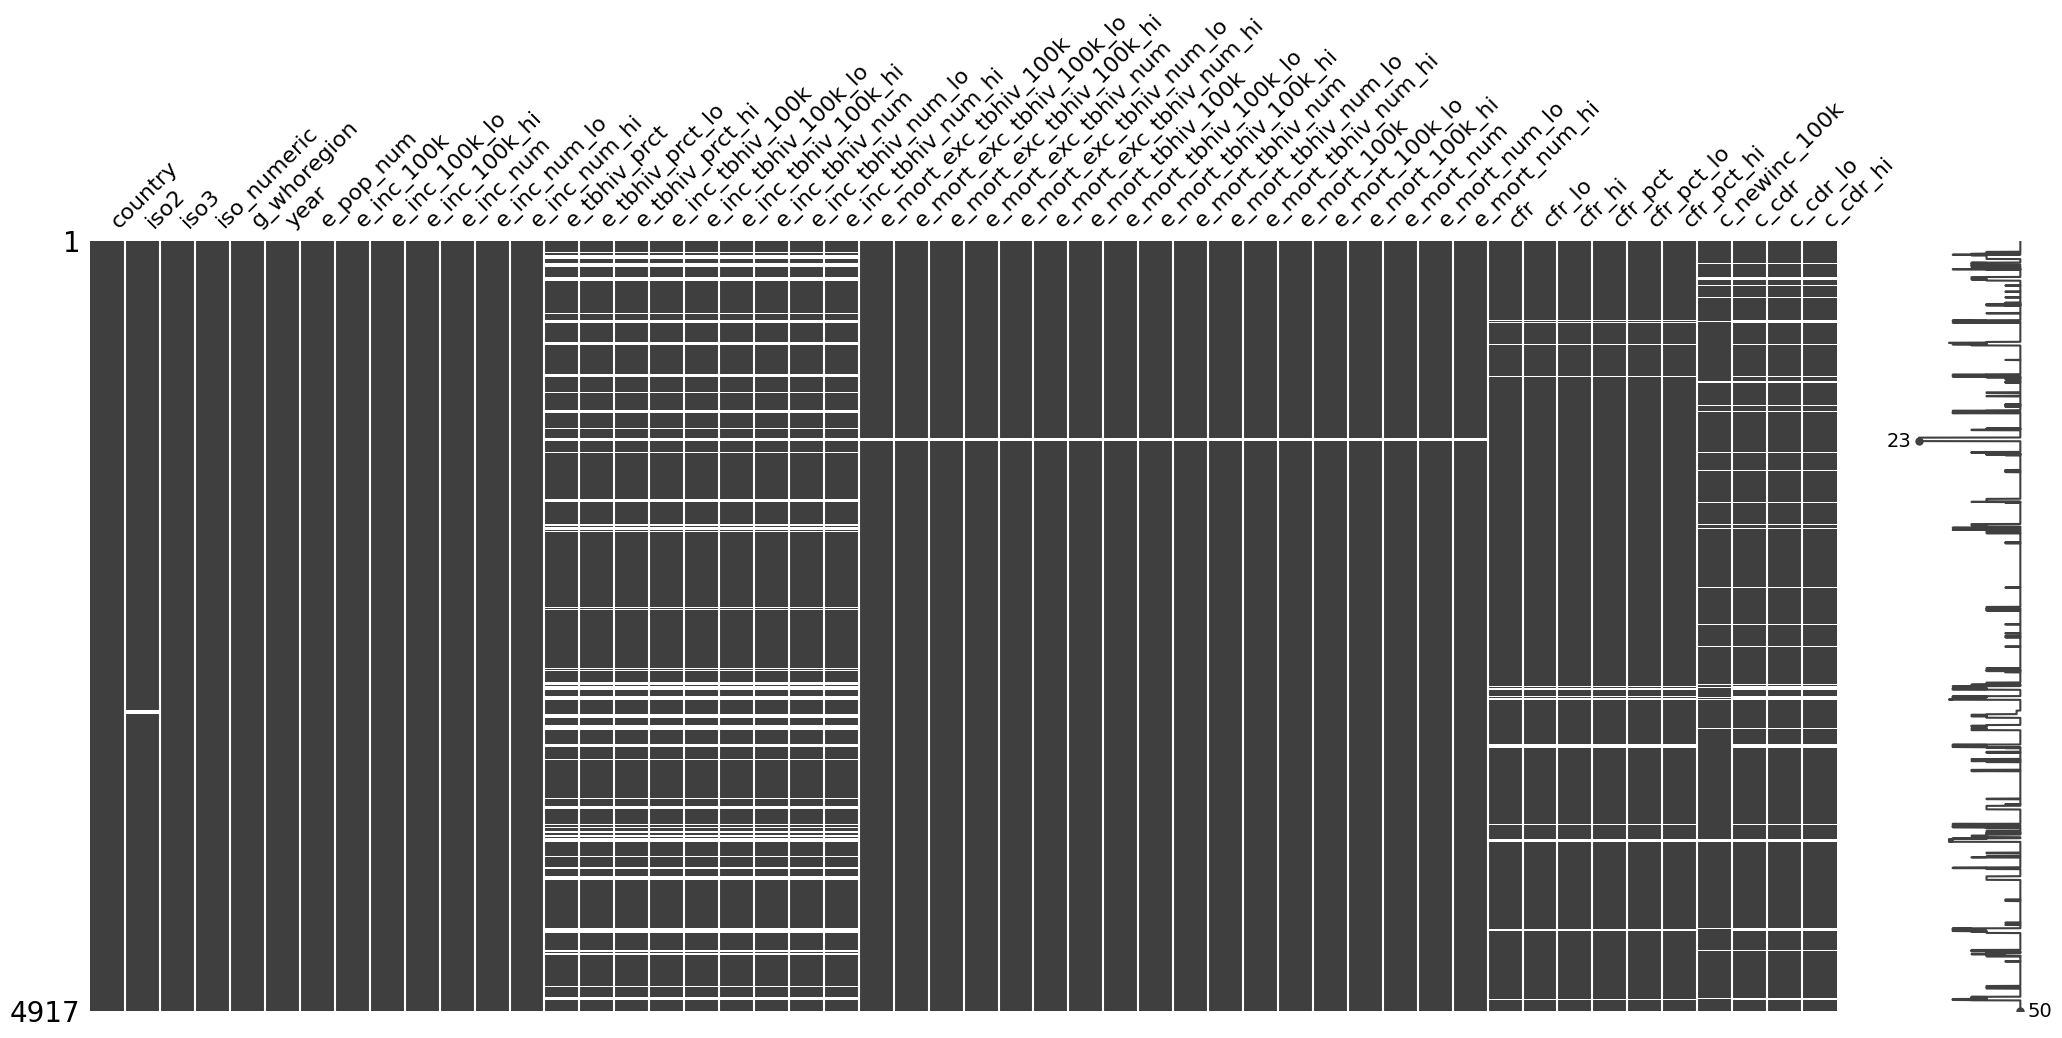

In [18]:
# Visualize the missing data
msno.matrix(tb_burden_countries_df)

### The tb_burden_countries audit:
Reveals that core epidemiological features like estimated incidence (e_inc_100k) and population (e_pop_num) are 100% complete, providing a robust "anchor" for the ranking system. However, columns related to HIV-TB co-infection show a 13.9% missing rate, which may require regional averaging to prevent the exclusion of key districts during donor preference matching. The Case Detection Rate (c_cdr) is missing for approximately 6% of entries, yet remains a vital performance metric for identifying regions that lack adequate diagnostic tools despite high disease burden. Descriptive statistics show massive variance in incidence rates (ranging from 0 to 1,590 per 100k), confirming that simple averages are insufficient and justifying the need for Phase 2 Clustering. Overall, the high integrity of primary join keys (iso3, year) ensures that these diverse features can be successfully integrated into a unified recommendation engine.

# **Laboratories**
The laboratories with their diagnostic capabilities

In [19]:
# Load the laboratories file into a dataframe
laboratories_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - TB_laboratories_2024-03-21.csv')
laboratories_df = pd.read_csv(laboratories_path)

# Display the head of the dataframe
display(laboratories_df.head())

,country,iso2,iso3,iso_numeric,g_whoregion,year,lab_sm,lab_sm_eqa,lab_sm_eqa_pass,lab_sm_led,...,dst_moxlev,dst_moxlev_eqa_pass,dst_bdq,dst_bdq_eqa_pass,dst_lzd,dst_lzd_eqa_pass,iso15189_accredited,qms_pending,lmis,m_wrd_etrans
0,Afghanistan,AF,AFG,4,EMR,2009,596.0,424.0,360.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AF,AFG,4,EMR,2010,600.0,476.0,396.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AF,AFG,4,EMR,2011,600.0,570.0,502.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,4,EMR,2012,603.0,0.0,0.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,4,EMR,2013,667.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Display the shape of the laboratories dataframe
print(laboratories_df.shape)

(3007, 74)


In [21]:
# Display the columns and their data types
print(laboratories_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3007 entries, 0 to 3006
Data columns (total 74 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                3007 non-null   object 
 1   iso2                   2993 non-null   object 
 2   iso3                   3007 non-null   object 
 3   iso_numeric            3007 non-null   int64  
 4   g_whoregion            3007 non-null   object 
 5   year                   3007 non-null   int64  
 6   lab_sm                 927 non-null    float64
 7   lab_sm_eqa             876 non-null    float64
 8   lab_sm_eqa_pass        824 non-null    float64
 9   lab_sm_led             555 non-null    float64
 10  lab_cul                912 non-null    float64
 11  lab_dst                910 non-null    float64
 12  lab_dst_eqa            857 non-null    float64
 13  lab_dst_eqa_pass       817 non-null    float64
 14  lab_lpa                851 non-null    float64
 15  lab_

In [22]:
# Display descriptive statistics for the laboratories dataframe
display(laboratories_df.describe())

,iso_numeric,year,lab_sm,lab_sm_eqa,lab_sm_eqa_pass,lab_sm_led,lab_cul,lab_dst,lab_dst_eqa,lab_dst_eqa_pass,...,dst_moxlev,dst_moxlev_eqa_pass,dst_bdq,dst_bdq_eqa_pass,dst_lzd,dst_lzd_eqa_pass,iso15189_accredited,qms_pending,lmis,m_wrd_etrans
count,3007.000000,3007.000000,927.000000,876.000000,824.000000,555.000000,912.000000,910.000000,857.000000,817.000000,...,467.000000,140.000000,464.000000,137.000000,465.000000,137.000000,437.000000,425.000000,441.000000,440.000000
mean,432.970070,2015.506152,437.249191,332.968037,263.775485,21.882883,35.781798,7.887912,5.883314,4.794370,...,6.434690,5.607143,1.530172,0.905109,2.036559,1.299270,4.254005,24.160000,256.673469,32.215909
std,252.679815,4.029071,1276.861361,1171.570643,852.555971,84.092344,141.389108,27.352536,20.645266,15.880353,...,42.397484,38.505105,5.762315,3.645874,7.422354,4.347692,15.479996,167.054739,2171.250647,110.284830
min,4.000000,2009.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,212.000000,2012.000000,18.000000,6.000000,4.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,434.000000,2016.000000,98.000000,51.000000,38.000000,1.000000,3.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,1.000000
75%,646.000000,2019.000000,268.500000,201.000000,177.000000,9.000000,15.000000,4.000000,2.000000,2.000000,...,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000,31.000000,13.250000
max,894.000000,2022.000000,13583.000000,13583.000000,11710.000000,1120.000000,1825.000000,399.000000,323.000000,222.000000,...,525.000000,448.000000,64.000000,34.000000,83.000000,34.000000,140.000000,2299.000000,28209.000000,1797.000000


In [23]:
# Calculate the number of missing values
missing_values_count = laboratories_df.isnull().sum()

# Calculate the percentage of missing values
missing_values_percentage = (missing_values_count / len(laboratories_df)) * 100

# Create a dataframe to display the results
missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

# Sort the dataframe by missing percentage in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the dataframe
display(missing_values_df)

,Missing Count,Missing Percentage (%)
dst_lzd_eqa_pass,2870,95.443964
dst_bdq_eqa_pass,2870,95.443964
lpa_sl_eqa_pass,2869,95.410708
dst_moxlev_eqa_pass,2867,95.344197
m_wrd_eqa_pass,2867,95.344197
...,...,...
year,0,0.000000
g_whoregion,0,0.000000
iso_numeric,0,0.000000
iso3,0,0.000000


<Axes: >

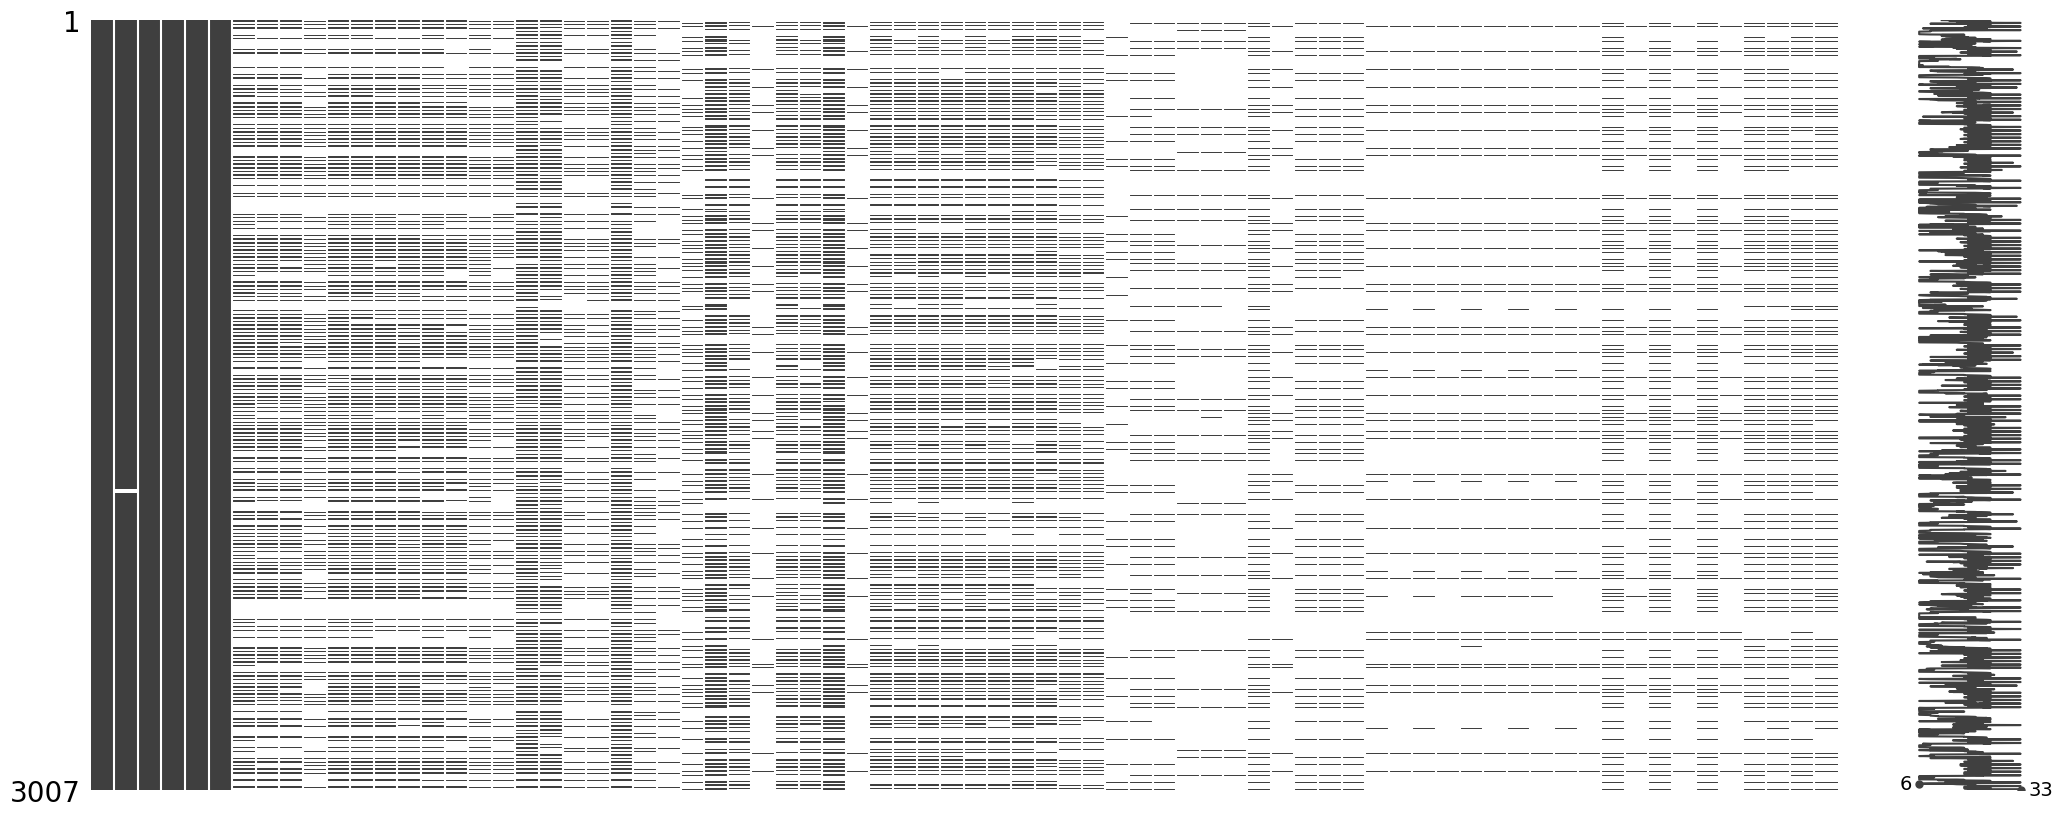

In [24]:
# Visualize the missing data
msno.matrix(laboratories_df)

### The Laboratory audit: 
Reveals significant data sparsity, with specialized diagnostic metrics like Bedaquiline DST (dst_bdq) missing in over 95% of the records. This high level of "missingness" indicates that we cannot rely on advanced quality-assurance variables to rank infrastructure but must instead pivot to more baseline features like Smear Microscopy (lab_sm) and Xpert machine counts. Descriptive statistics highlight that reporting has improved over time (2009–2022), suggesting that our recommendation engine should prioritize the most recent data cycle for accuracy. We must also account for the massive variance in lab counts (standard deviations often exceeding the mean), which reinforces the need for feature normalization in Phase 2. Moving forward, the "Infrastructure" score in our recommender will be built on these broader, more complete proxy variables rather than niche clinical tests.

### Subject matter expertise insight:
The massive variance in the std (Standard Deviation) column of the Laboratory audit shows that lab capacity isn't just randomly missing; it’s clustered. This means that a country's WHO Region or Income Group is likely a strong predictor of its infrastructure capacity.

### Suggested strategy:
Regional Imputation: For countries with missing lab_xpert counts, we can "fill" those gaps using the median value of their specific WHO Region (e.g., AFRO, SEARO, EURO) rather than a global average.

Capacity-to-Incidence Ratio: Instead of just looking at the number of labs, we should create a new feature: Labs per 100k Estimated Incidents. This will show us where the "Diagnostic Coverage" is truly lagging relative to the actual disease burden.

# **Budget**
Are there funding gaps leading to low laboratory diagnostic capacity?

In [25]:
# Load the budget file into a dataframe
budget_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - TB_budget_2024-03-21.csv')
budget_df = pd.read_csv(budget_path)

# Display the head of the dataframe
display(budget_df .head())

,country,iso2,iso3,iso_numeric,g_whoregion,year,tx_dstb,budget_cpp_dstb,tx_mdr,budget_cpp_mdr,...,cf_orsrvy,budget_oth,cf_oth,budget_tot,cf_tot,cf_tot_domestic,cf_tot_gf,cf_tot_usaid,cf_tot_grnt,cf_tot_sources
0,Afghanistan,AF,AFG,4,EMR,2018,52000.0,40.0,450.0,1400.0,...,344940.0,NaN,2912498.0,10881354.0,10698483.0,533779.0,3178499.0,4462530.0,2523675.0,10698483.0
1,Afghanistan,AF,AFG,4,EMR,2019,53000.0,50.0,585.0,1500.0,...,59000.0,5344361.0,5171641.0,16957452.0,13419792.0,511854.0,6533095.0,2766449.0,3608394.0,13419792.0
2,Afghanistan,AF,AFG,4,EMR,2020,57000.0,40.0,580.0,1000.0,...,400000.0,4000000.0,3600775.0,19137128.0,17978424.0,1171864.0,6935551.0,3000000.0,6871009.0,17978424.0
3,Afghanistan,AF,AFG,4,EMR,2021,53825.0,50.0,725.0,1000.0,...,127420.0,3606831.0,3606831.0,10633599.0,10633599.0,NaN,7638546.0,NaN,2995053.0,10633599.0
4,Afghanistan,AF,AFG,4,EMR,2022,56795.0,50.0,600.0,1000.0,...,67310.0,3529753.0,3529753.0,14141821.0,10599950.0,269339.0,6876137.0,1555946.0,1898528.0,10599950.0


In [26]:
# Display the shape of the budget dataframe
print(budget_df.shape)

(1290, 43)


In [27]:
# Display the columns and their data types
print(budget_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290 entries, 0 to 1289
Data columns (total 43 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          1290 non-null   object 
 1   iso2             1284 non-null   object 
 2   iso3             1290 non-null   object 
 3   iso_numeric      1290 non-null   int64  
 4   g_whoregion      1290 non-null   object 
 5   year             1290 non-null   int64  
 6   tx_dstb          675 non-null    float64
 7   budget_cpp_dstb  645 non-null    float64
 8   tx_mdr           671 non-null    float64
 9   budget_cpp_mdr   641 non-null    float64
 10  tx_xdr           601 non-null    float64
 11  budget_cpp_xdr   548 non-null    float64
 12  tx_tpt           417 non-null    float64
 13  budget_cpp_tpt   398 non-null    float64
 14  budget_lab       627 non-null    float64
 15  cf_lab           625 non-null    float64
 16  budget_staff     620 non-null    float64
 17  cf_staff      

In [28]:
# Display the statistics
display(budget_df.describe())

,iso_numeric,year,tx_dstb,budget_cpp_dstb,tx_mdr,budget_cpp_mdr,tx_xdr,budget_cpp_xdr,tx_tpt,budget_cpp_tpt,...,cf_orsrvy,budget_oth,cf_oth,budget_tot,cf_tot,cf_tot_domestic,cf_tot_gf,cf_tot_usaid,cf_tot_grnt,cf_tot_sources
count,1290.000000,1290.000000,6.750000e+02,645.000000,671.000000,641.000000,601.000000,548.000000,4.170000e+02,398.000000,...,5.730000e+02,5.490000e+02,5.490000e+02,8.280000e+02,6.470000e+02,6.130000e+02,6.090000e+02,4.860000e+02,5.220000e+02,6.510000e+02
mean,433.200000,2020.500000,6.971284e+04,643.520930,1771.289121,4087.909516,198.487521,6129.686131,6.829640e+04,238.047739,...,5.065491e+05,5.808363e+06,5.131192e+06,4.821886e+07,4.536160e+07,3.764077e+07,7.720473e+06,2.156765e+06,1.006146e+06,4.508288e+07
std,252.731072,1.708487,2.510765e+05,8635.770672,6380.153558,20521.604218,1001.431877,13795.832530,2.721303e+05,2329.065509,...,2.336147e+06,3.364157e+07,3.336654e+07,1.619825e+08,1.701110e+08,1.706683e+08,1.541045e+07,4.982339e+06,3.257675e+06,1.696239e+08
min,4.000000,2018.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.140000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,212.000000,2019.000000,2.531000e+03,32.000000,42.500000,960.000000,1.000000,968.500000,1.153000e+03,8.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,1.200075e+06,1.842548e+06,4.629740e+05,6.227300e+05,0.000000e+00,0.000000e+00,1.815822e+06
50%,434.000000,2020.500000,8.676000e+03,47.000000,167.000000,1511.000000,5.000000,3322.000000,4.550000e+03,15.000000,...,5.644200e+04,2.054400e+05,1.204240e+05,6.380376e+06,6.901734e+06,2.216505e+06,2.420250e+06,0.000000e+00,4.271450e+04,6.828768e+06
75%,646.000000,2022.000000,3.167350e+04,72.000000,675.500000,2831.000000,30.000000,6240.000000,2.253500e+04,29.000000,...,2.270870e+05,1.878000e+06,1.057467e+06,2.665690e+07,2.053400e+07,1.003955e+07,6.358284e+06,5.486218e+05,6.023748e+05,2.044500e+07
max,894.000000,2023.000000,3.000000e+06,174700.000000,71000.000000,400000.000000,13200.000000,250000.000000,3.500000e+06,30000.000000,...,3.430065e+07,3.617290e+08,3.617290e+08,1.640128e+09,1.640128e+09,1.639948e+09,1.596484e+08,2.500000e+07,4.000000e+07,1.640128e+09


In [29]:
# Calculate the number of missing values
missing_values_count = budget_df.isnull().sum()

# Calculate the percentage of missing values
missing_values_percentage = (missing_values_count / len(budget_df)) * 100

# Create a dataframe to display the results
missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

# Sort the dataframe by missing percentage in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the dataframe
display(missing_values_df)

,Missing Count,Missing Percentage (%)
cf_tpt,913,70.775194
budget_tpt,903,70.000000
budget_cpp_tpt,892,69.147287
tx_tpt,873,67.674419
cf_tot_usaid,804,62.325581
cf_tot_grnt,768,59.534884
budget_cpp_xdr,742,57.519380
cf_oth,741,57.441860
budget_oth,741,57.441860
cf_orsrvy,717,55.581395


<Axes: >

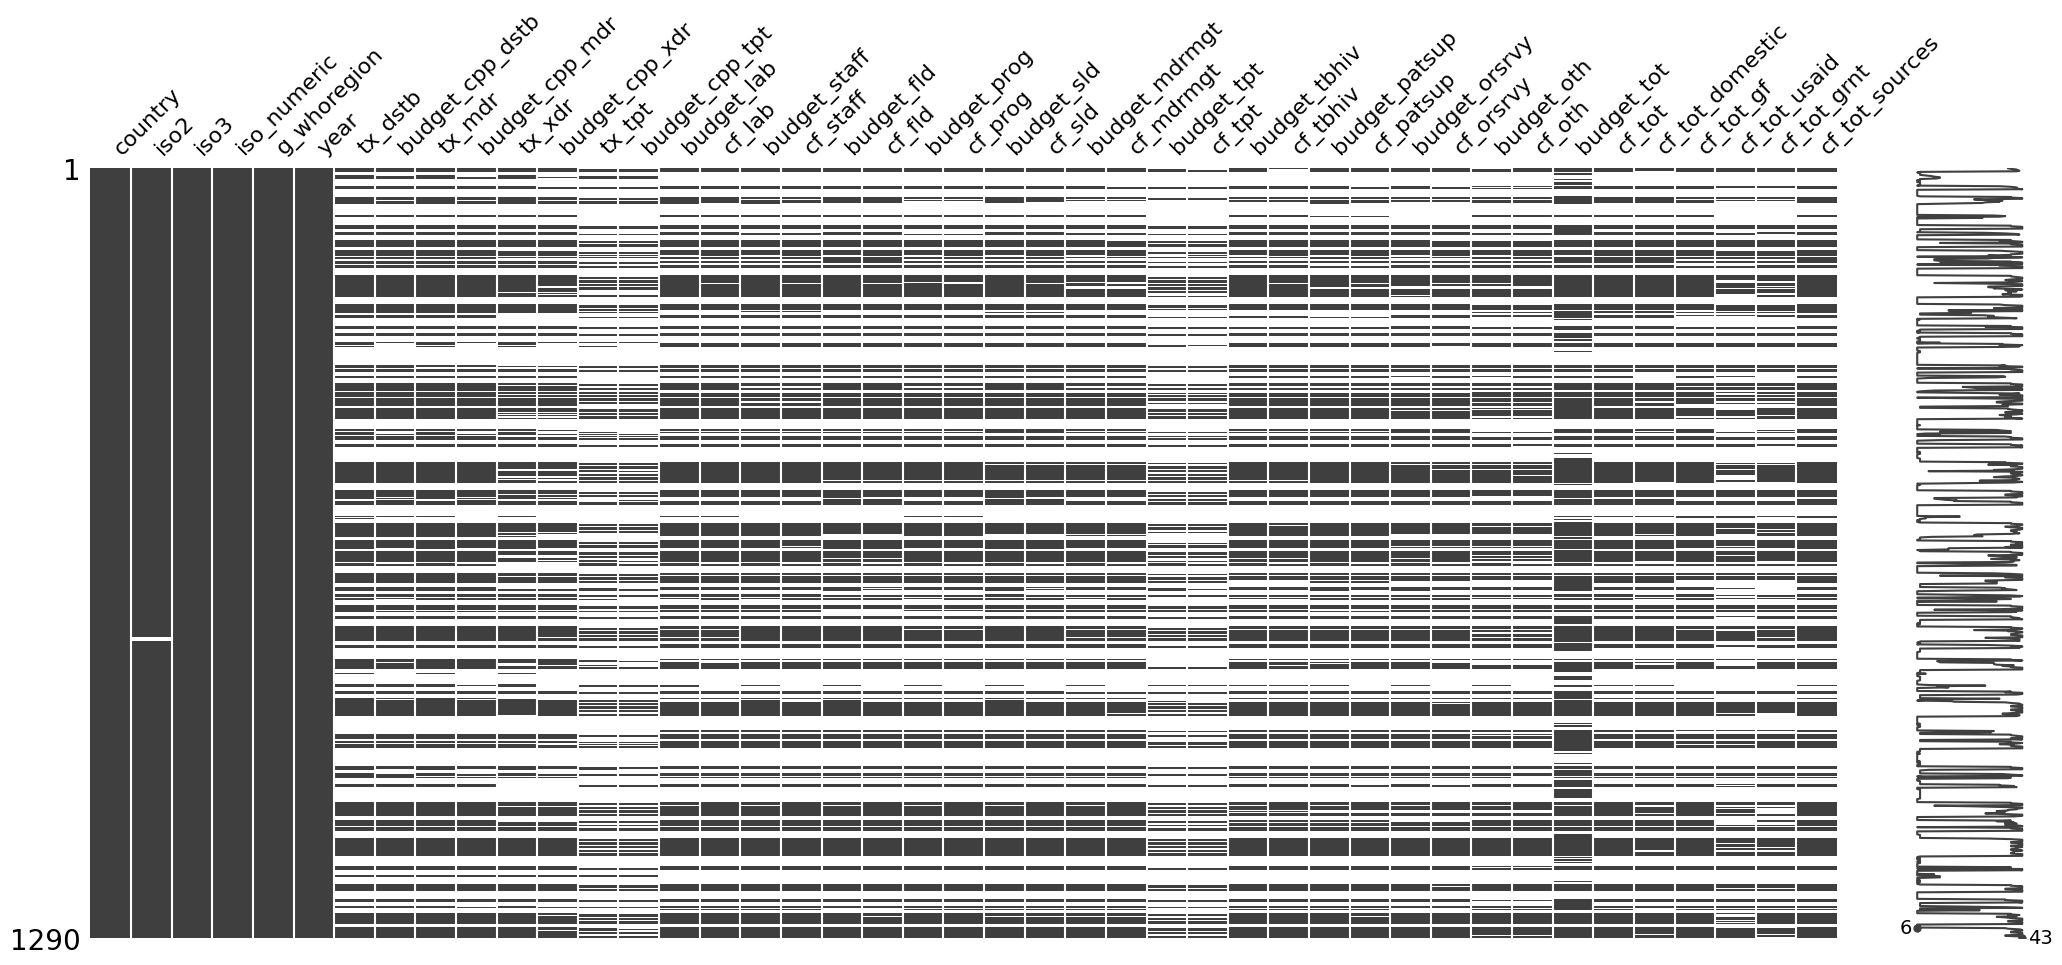

In [30]:
msno.matrix(budget_df)

### The Budget audit:
Identifies a significant "Financial Transparency Gap," with the total required budget (budget_tot) missing for nearly 36% of the dataset. Granular funding data for laboratory infrastructure (budget_lab) and staff is even scarcer, with over 51% of records lacking these details, echoing the geographic disparities seen in the laboratory capacity audit. This missingness is strategically valuable, as districts that fail to report budgets despite high disease burden represent primary targets for organizational capacity building. By integrating the "Self-Sufficiency Ratio" (domestic vs. external funding), the recommender can distinguish between countries that are underfunded and those that are simply under-reporting. Consequently, Phase 2 will focus on using these financial indicators to rank districts not just by medical need, but by their economic readiness for new diagnostic interventions.

# **Expenditure Utilisation**
Which funds were actually spent?

In [31]:
# Load the expenditure file into a dataframe
expenditure_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - TB_expenditure_utilisation_2024.csv')
expenditure_df = pd.read_csv(expenditure_path)

# Display the head of the dataframe
display(budget_df .head())

,country,iso2,iso3,iso_numeric,g_whoregion,year,tx_dstb,budget_cpp_dstb,tx_mdr,budget_cpp_mdr,...,cf_orsrvy,budget_oth,cf_oth,budget_tot,cf_tot,cf_tot_domestic,cf_tot_gf,cf_tot_usaid,cf_tot_grnt,cf_tot_sources
0,Afghanistan,AF,AFG,4,EMR,2018,52000.0,40.0,450.0,1400.0,...,344940.0,NaN,2912498.0,10881354.0,10698483.0,533779.0,3178499.0,4462530.0,2523675.0,10698483.0
1,Afghanistan,AF,AFG,4,EMR,2019,53000.0,50.0,585.0,1500.0,...,59000.0,5344361.0,5171641.0,16957452.0,13419792.0,511854.0,6533095.0,2766449.0,3608394.0,13419792.0
2,Afghanistan,AF,AFG,4,EMR,2020,57000.0,40.0,580.0,1000.0,...,400000.0,4000000.0,3600775.0,19137128.0,17978424.0,1171864.0,6935551.0,3000000.0,6871009.0,17978424.0
3,Afghanistan,AF,AFG,4,EMR,2021,53825.0,50.0,725.0,1000.0,...,127420.0,3606831.0,3606831.0,10633599.0,10633599.0,NaN,7638546.0,NaN,2995053.0,10633599.0
4,Afghanistan,AF,AFG,4,EMR,2022,56795.0,50.0,600.0,1000.0,...,67310.0,3529753.0,3529753.0,14141821.0,10599950.0,269339.0,6876137.0,1555946.0,1898528.0,10599950.0


In [32]:
# Display the shape of the expenditure_df dataframe
print(expenditure_df.shape)

(1290, 46)


In [33]:
# Display the columns and their data types
print(expenditure_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290 entries, 0 to 1289
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            1290 non-null   object 
 1   iso2               1284 non-null   object 
 2   iso3               1290 non-null   object 
 3   iso_numeric        1290 non-null   int64  
 4   g_whoregion        1290 non-null   object 
 5   year               1290 non-null   int64  
 6   exp_cpp_dstb       611 non-null    float64
 7   exp_cpp_mdr        607 non-null    float64
 8   exp_cpp_xdr        536 non-null    float64
 9   exp_cpp_tpt        369 non-null    float64
 10  exp_lab            586 non-null    float64
 11  rcvd_lab           591 non-null    float64
 12  exp_staff          588 non-null    float64
 13  rcvd_staff         590 non-null    float64
 14  exp_fld            604 non-null    float64
 15  rcvd_fld           607 non-null    float64
 16  exp_prog           569 n

In [34]:
# Display the statistics
display(expenditure_df.describe())

,iso_numeric,year,exp_cpp_dstb,exp_cpp_mdr,exp_cpp_xdr,exp_cpp_tpt,exp_lab,rcvd_lab,exp_staff,rcvd_staff,...,rcvd_tot_usaid,rcvd_tot_grnt,rcvd_tot_sources,hcfvisit_dstb,hcfvisit_mdr,hospd_dstb_prct,hospd_mdr_prct,hospd_dstb_dur,hospd_mdr_dur,hosp_type_mdr
count,1290.000000,1290.000000,6.110000e+02,6.070000e+02,536.000000,3.690000e+02,5.860000e+02,5.910000e+02,5.880000e+02,5.900000e+02,...,4.560000e+02,4.940000e+02,6.290000e+02,996.000000,941.000000,1011.000000,986.000000,999.000000,949.000000,1116.000000
mean,433.200000,2019.500000,2.125383e+04,1.423751e+04,4617.882463,3.953566e+03,3.582585e+06,3.869330e+06,1.505781e+07,1.507727e+07,...,1.710407e+06,8.942417e+05,4.006942e+07,70.505020,168.028693,38.421365,59.778905,23.068068,75.938883,125.823477
std,252.731072,1.708487,5.085984e+05,2.749804e+05,7394.592177,7.062286e+04,1.100315e+07,1.135724e+07,9.346224e+07,9.330137e+07,...,3.908623e+06,3.042635e+06,1.629575e+08,410.304543,215.778758,35.791067,41.094664,23.902637,76.441840,44.001572
min,4.000000,2017.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,212.000000,2018.000000,3.300000e+01,9.730000e+02,0.000000,6.000000e+00,2.065275e+05,2.335825e+05,2.292595e+05,2.470688e+05,...,0.000000e+00,0.000000e+00,1.721076e+06,8.000000,15.000000,5.000000,15.000000,10.000000,20.000000,141.000000
50%,434.000000,2019.500000,4.900000e+01,1.606000e+03,2797.500000,1.500000e+01,8.770240e+05,9.496640e+05,9.323945e+05,9.900000e+05,...,0.000000e+00,4.787200e+04,6.431866e+06,24.000000,64.000000,25.000000,80.000000,15.000000,60.000000,142.000000
75%,646.000000,2021.000000,7.500000e+01,2.857000e+03,5577.500000,2.900000e+01,2.507328e+06,2.684831e+06,3.304612e+06,3.340018e+06,...,6.110970e+05,6.654882e+05,1.827455e+07,78.250000,270.000000,73.000000,100.000000,30.000000,120.000000,142.000000
max,894.000000,2022.000000,1.256972e+07,6.772522e+06,60000.000000,1.355915e+06,1.804837e+08,1.810761e+08,1.016896e+09,1.016896e+09,...,2.200000e+07,5.576166e+07,1.640128e+09,12532.000000,2700.000000,100.000000,100.000000,404.000000,720.000000,142.000000


In [35]:
# Calculate the number of missing values
missing_values_count = expenditure_df.isnull().sum()

# Calculate the percentage of missing values
missing_values_percentage = (missing_values_count / len(expenditure_df)) * 100

# Create a dataframe to display the results
missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

# Sort the dataframe by missing percentage in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the dataframe
display(missing_values_df)

,Missing Count,Missing Percentage (%)
exp_tpt,950,73.643411
rcvd_tpt,949,73.565891
exp_cpp_tpt,921,71.395349
rcvd_tot_usaid,834,64.651163
rcvd_tot_grnt,796,61.705426
rcvd_oth,754,58.449612
exp_oth,754,58.449612
exp_cpp_xdr,754,58.449612
exp_orsrvy,746,57.829457
rcvd_orsrvy,741,57.441860


<Axes: >

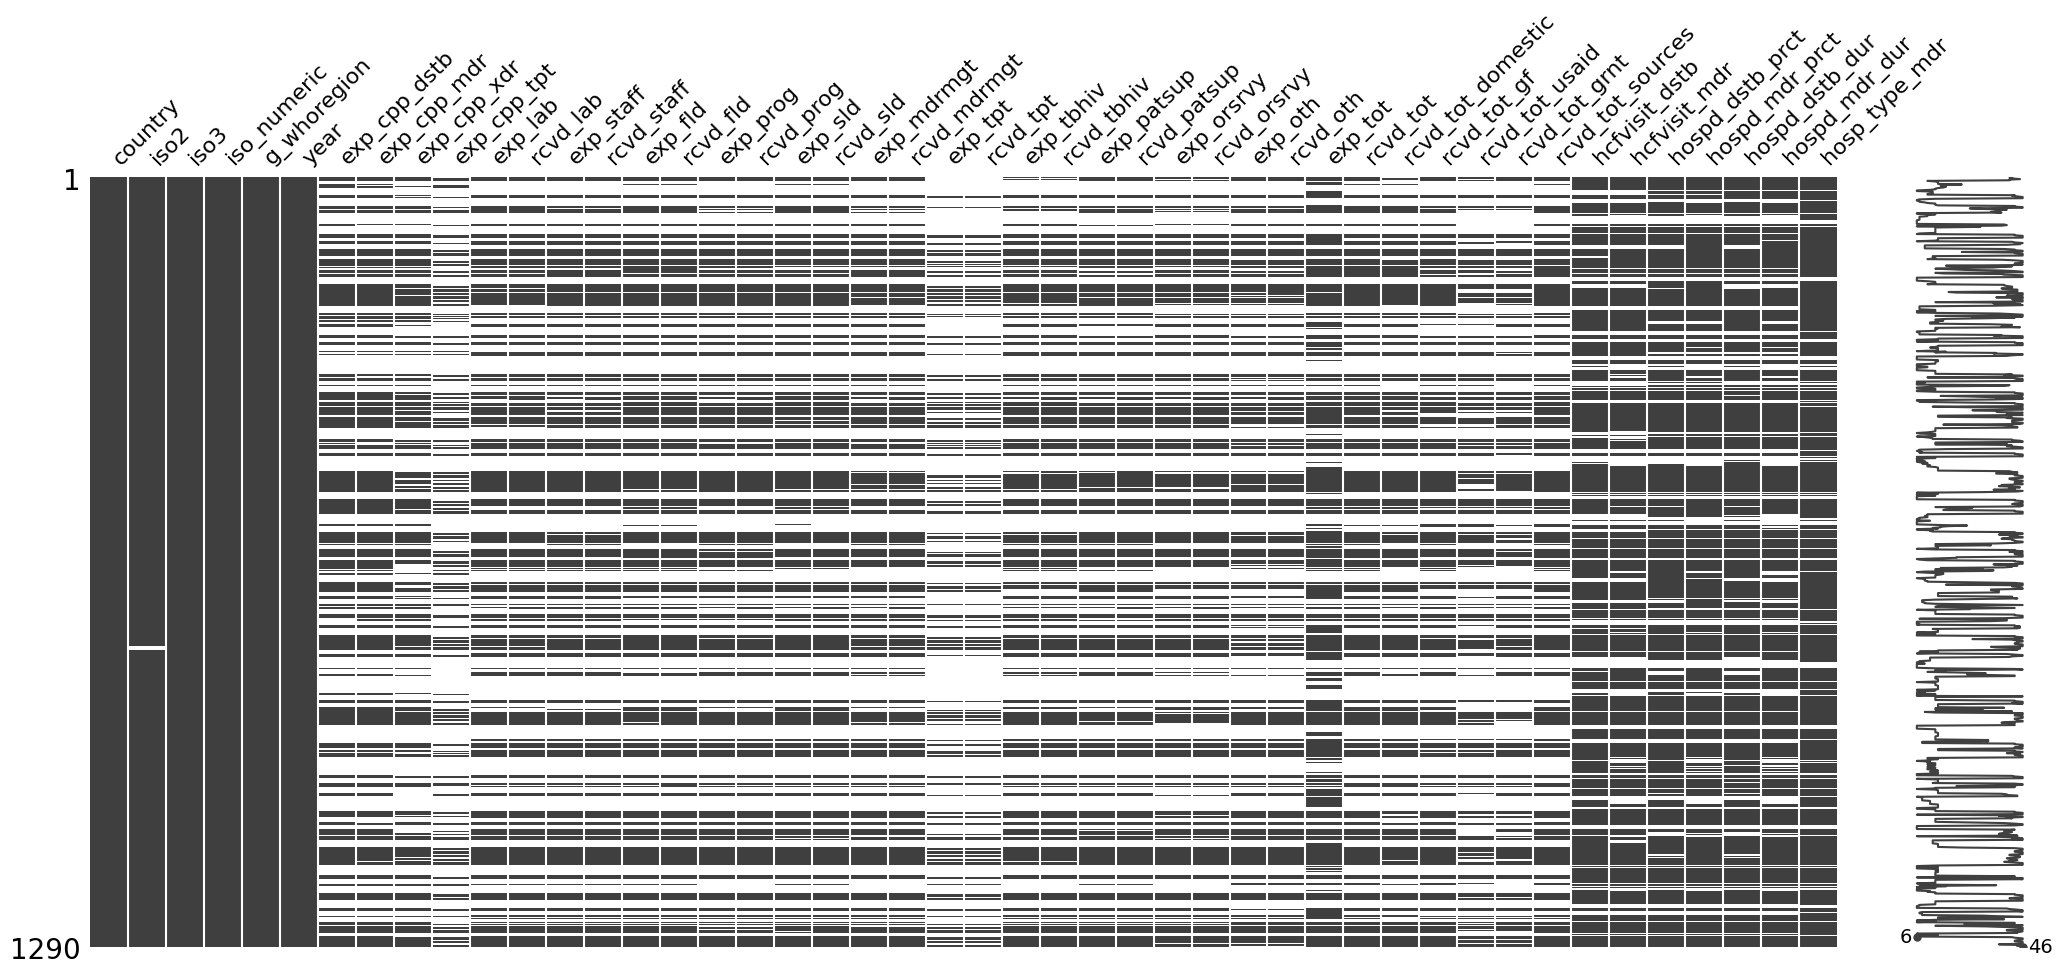

In [36]:
# Visualize the missing data
msno.matrix(expenditure_df)

### The Expenditure audit:
Reveals an "Implementation Gap," where total spending data (exp_tot) is missing for 38% of entries, often even when a budget was previously defined. Massive variance in costs per patient (exp_cpp_dstb) confirms that geographic and systemic factors create vast differences in how efficiently funds are converted into patient care. Interestingly, utilization metrics like hospitalization duration and facility visits are more consistently reported (missing in only ~22% of cases), offering a more reliable proxy for system activity than raw financial figures. By combining these, the recommender can identify "Under-resourced Over-performers"—districts with high patient throughput despite low or missing reported expenditure. This completes Phase 1, shifting our focus to a "Unified Master Table" that balances disease burden, diagnostic capacity, and financial efficiency.

# **Outcomes**
Is the system actually effective?

In [37]:
# Load the outcomes file into a dataframe
outcomes_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - TB_outcomes_2024-03-21.csv')
outcomes_df = pd.read_csv(outcomes_path)

# Display the head of the dataframe
display(outcomes_df .head())

,country,iso2,iso3,iso_numeric,g_whoregion,year,rep_meth,new_sp_coh,new_sp_cur,new_sp_cmplt,...,mdr_coh,mdr_succ,mdr_fail,mdr_died,mdr_lost,xdr_coh,xdr_succ,xdr_fail,xdr_died,xdr_lost
0,Afghanistan,AF,AFG,4,EMR,1994,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AF,AFG,4,EMR,1995,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AF,AFG,4,EMR,1996,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,4,EMR,1997,100.0,2001.0,786.0,108.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,4,EMR,1998,100.0,2913.0,772.0,199.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# Display the shape of the outcomes_df dataframe
print(outcomes_df.shape)

(5969, 73)


In [39]:
# Display the columns and their data types
print(outcomes_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5969 entries, 0 to 5968
Data columns (total 73 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             5969 non-null   object 
 1   iso2                5941 non-null   object 
 2   iso3                5969 non-null   object 
 3   iso_numeric         5969 non-null   int64  
 4   g_whoregion         5969 non-null   object 
 5   year                5969 non-null   int64  
 6   rep_meth            3034 non-null   float64
 7   new_sp_coh          3052 non-null   float64
 8   new_sp_cur          2945 non-null   float64
 9   new_sp_cmplt        2943 non-null   float64
 10  new_sp_died         2992 non-null   float64
 11  new_sp_fail         2876 non-null   float64
 12  new_sp_def          2954 non-null   float64
 13  c_new_sp_tsr        3006 non-null   float64
 14  new_snep_coh        1301 non-null   float64
 15  new_snep_cmplt      1289 non-null   float64
 16  new_sn

In [40]:
# Display the statistics
display(outcomes_df.describe())

,iso_numeric,year,rep_meth,new_sp_coh,new_sp_cur,new_sp_cmplt,new_sp_died,new_sp_fail,new_sp_def,c_new_sp_tsr,...,mdr_coh,mdr_succ,mdr_fail,mdr_died,mdr_lost,xdr_coh,xdr_succ,xdr_fail,xdr_died,xdr_lost
count,5969.000000,5969.000000,3034.000000,3052.000000,2945.000000,2943.000000,2992.000000,2876.000000,2954.000000,3006.000000,...,2694.000000,2619.000000,2537.000000,2587.000000,2572.000000,2078.000000,1980.000000,1965.000000,1970.000000,1965.000000
mean,432.071704,2007.562071,100.271589,10874.190039,7895.221392,965.705063,431.336230,184.123088,613.544685,75.762475,...,458.427988,265.733486,40.911707,69.780441,69.678849,42.443215,19.807576,6.985242,9.949746,4.793893
std,253.560626,8.075478,0.646125,45628.377725,37514.772254,3325.334388,1616.200795,812.662201,2387.185755,16.293690,...,2657.242476,1475.995177,319.563298,428.651183,416.143013,348.380637,180.953772,59.823095,76.635531,37.541488
min,4.000000,1994.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,212.000000,2001.000000,100.000000,127.500000,66.000000,13.000000,7.000000,0.000000,5.000000,69.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,430.000000,2008.000000,100.000000,1233.000000,721.000000,124.000000,60.000000,15.000000,91.000000,79.000000,...,14.000000,9.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,646.000000,2015.000000,100.000000,5368.250000,3399.000000,585.000000,257.000000,99.000000,394.500000,86.750000,...,96.750000,64.000000,2.000000,13.000000,11.000000,2.000000,1.000000,0.000000,0.000000,0.000000
max,894.000000,2021.000000,102.000000,642321.000000,544731.000000,64938.000000,27005.000000,12505.000000,35469.000000,100.000000,...,60858.000000,34891.000000,9260.000000,7985.000000,8051.000000,8950.000000,5726.000000,1237.000000,1579.000000,831.000000


In [41]:
# Calculate the number of missing values
missing_values_count = outcomes_df.isnull().sum()

# Calculate the percentage of missing values
missing_values_percentage = (missing_values_count / len(outcomes_df)) * 100

# Create a dataframe to display the results
missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

# Sort the dataframe by missing percentage in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the dataframe
display(missing_values_df)

,Missing Count,Missing Percentage (%)
used_2021_defs_flg,5581,93.499749
hiv_ret_fail,5294,88.691573
hiv_new_snep_fail,5287,88.574301
hiv_ret_cur,5281,88.473781
hiv_ret_def,5277,88.406768
...,...,...
iso_numeric,0,0.000000
g_whoregion,0,0.000000
iso3,0,0.000000
year,0,0.000000


<Axes: >

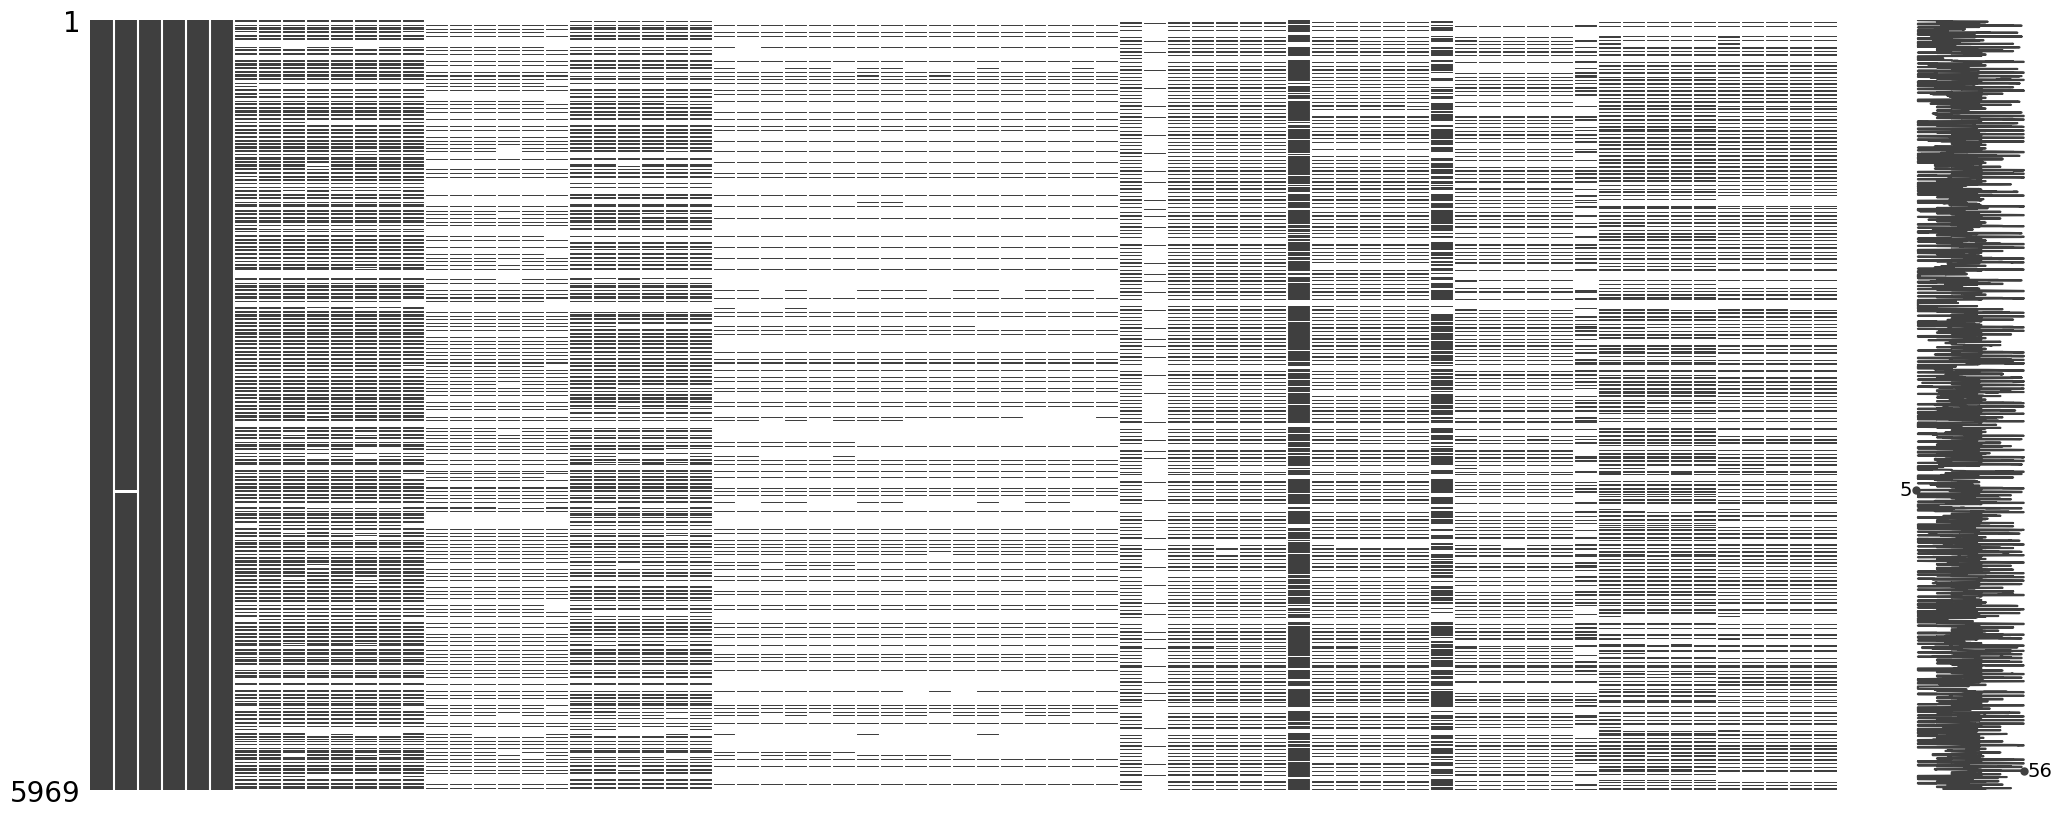

In [42]:
# Visualize the missing data
msno.matrix(outcomes_df)

### The Outcomes audit:
Provides the critical clinical "Ground Truth" for the recommender, with the Treatment Success Rate (c_new_sp_tsr) serving as the primary indicator of health system performance. While standard TB outcomes are relatively well-reported, the significant drop in data for MDR and XDR cohorts highlights a lack of specialized diagnostic and follow-up capacity in many regions. The average success rate of ~76% sits well below the WHO 85% target, identifying a widespread need for the improved diagnostic tools the project aims to recommend. Massive variance in cohort sizes (ranging from single digits to over 600,000) necessitates feature scaling to ensure smaller, high-risk districts are not overshadowed by high-volume nations. By integrating these success metrics with the previously audited burden and financial data, the model can now distinguish between districts that are simply underfunded and those that are operationally struggling to cure patients.

# **Policies**
Has a country actually adopted specific WHO-recommended policies (e.g., rapid diagnostic algorithms)?

In [43]:
# Load the policies file into a dataframe
policies_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - TB_policies_services_2024-03-21.csv')
policies_df = pd.read_csv(policies_path)

# Display the head of the dataframe
display(policies_df.head())

,country,iso2,iso3,iso_numeric,g_whoregion,year,caseb_err_nat,hcw_tb_infected,hcw_tot,exp_res
0,Afghanistan,AF,AFG,4,EMR,2022,0.0,NaN,NaN,NaN
1,Albania,AL,ALB,8,EUR,2022,42.0,NaN,NaN,NaN
2,Algeria,DZ,DZA,12,AFR,2022,44.0,NaN,NaN,NaN
3,American Samoa,AS,ASM,16,WPR,2022,NaN,NaN,NaN,NaN
4,Andorra,AD,AND,20,EUR,2022,42.0,NaN,NaN,NaN


In [44]:
# Display the shape of the policies dataframe
print(policies_df.shape)

(215, 10)


In [45]:
# Display the columns and their data types
print(outcomes_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5969 entries, 0 to 5968
Data columns (total 73 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             5969 non-null   object 
 1   iso2                5941 non-null   object 
 2   iso3                5969 non-null   object 
 3   iso_numeric         5969 non-null   int64  
 4   g_whoregion         5969 non-null   object 
 5   year                5969 non-null   int64  
 6   rep_meth            3034 non-null   float64
 7   new_sp_coh          3052 non-null   float64
 8   new_sp_cur          2945 non-null   float64
 9   new_sp_cmplt        2943 non-null   float64
 10  new_sp_died         2992 non-null   float64
 11  new_sp_fail         2876 non-null   float64
 12  new_sp_def          2954 non-null   float64
 13  c_new_sp_tsr        3006 non-null   float64
 14  new_snep_coh        1301 non-null   float64
 15  new_snep_cmplt      1289 non-null   float64
 16  new_sn

In [46]:
# Display the statistics
display(policies_df.describe())

,iso_numeric,year,caseb_err_nat,hcw_tb_infected,hcw_tot,exp_res
count,215.000000,215.0,189.000000,90.000000,6.400000e+01,2.700000e+01
mean,433.200000,2022.0,34.772487,179.700000,5.164872e+05,3.015105e+05
std,253.222672,0.0,16.343262,659.511897,1.878372e+06,6.919940e+05
min,4.000000,2022.0,0.000000,0.000000,3.000000e+02,0.000000e+00
25%,213.000000,2022.0,42.000000,1.000000,1.322225e+04,0.000000e+00
50%,434.000000,2022.0,42.000000,20.000000,6.017150e+04,0.000000e+00
75%,644.500000,2022.0,42.000000,72.250000,3.247510e+05,1.865975e+05
max,894.000000,2022.0,44.000000,5188.000000,1.398536e+07,3.179046e+06


In [47]:
# Calculate the number of missing values
missing_values_count = policies_df.isnull().sum()

# Calculate the percentage of missing values
missing_values_percentage = (missing_values_count / len(policies_df)) * 100

# Create a dataframe to display the results
missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

# Sort the dataframe by missing percentage in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the dataframe
display(missing_values_df)

,Missing Count,Missing Percentage (%)
exp_res,188,87.441860
hcw_tot,151,70.232558
hcw_tb_infected,125,58.139535
caseb_err_nat,26,12.093023
iso2,1,0.465116
country,0,0.000000
iso3,0,0.000000
iso_numeric,0,0.000000
g_whoregion,0,0.000000
year,0,0.000000


<Axes: >

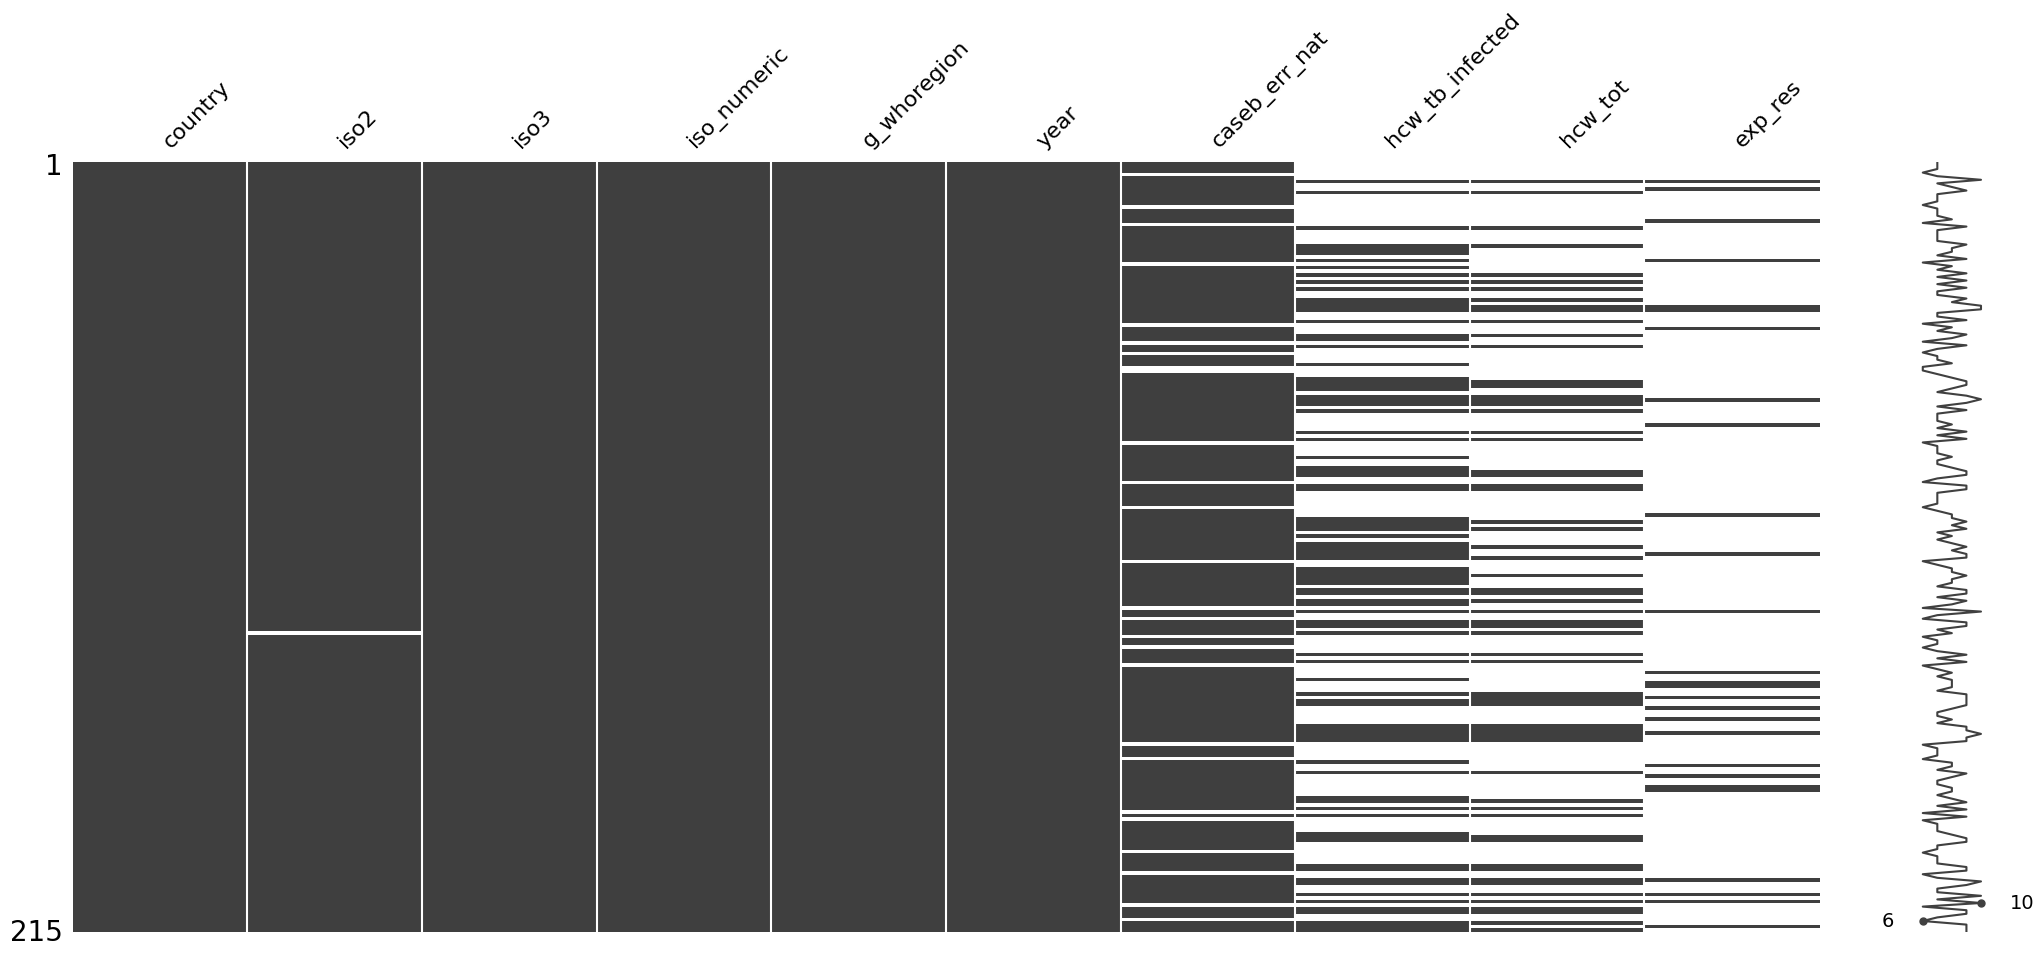

In [48]:
# Visualize the missing data
msno.matrix(policies_df)

### The Policies and Services audit:
Provides a critical 2022 snapshot of "Institutional Readiness," highlighting systemic risks such as TB infection rates among healthcare workers (hcw_tb_infected). With data missing for over 58% of infected HCW records and nearly 87% of research expenditure (exp_res), this file underscores a significant lack of occupational safety and innovation tracking in high-burden regions. These policy markers serve as "Current State" indicators that are best applied to the 2022 data cycle rather than historical trends. From a recommender perspective, districts exhibiting high HCW infection rates should be prioritized for automated, closed-system diagnostics to mitigate laboratory exposure risks. Integrating these categorical policy tags allows the final model to move beyond raw numbers and account for the safety and quality environment of each national TB program.

# **LTBI**
Estimates of Latent TB infection 

In [49]:
# Load the ltbi file into a dataframe
ltbi_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - LTBI_estimates_2024-03-21.csv')
ltbi_df = pd.read_csv(ltbi_path)

# Display the head of the dataframe
display(ltbi_df.head())

,country,iso2,iso3,iso_numeric,g_whoregion,year,source_hh,e_hh_size,prevtx_data_available,newinc_con_prevtx,...,e_hh_contacts_hi,e_prevtx_hh_contacts_pct,e_prevtx_hh_contacts_pct_lo,e_prevtx_hh_contacts_pct_hi,e_prevtx_eligible,e_prevtx_eligible_lo,e_prevtx_eligible_hi,e_prevtx_kids_pct,e_prevtx_kids_pct_lo,e_prevtx_kids_pct_hi
0,Afghanistan,AF,AFG,4,EMR,2022,DHS; 2015-10-19,8.036738,60.0,32250.0,...,170000.0,19.0,18.0,19.0,30000.0,27000.0,32000.0,100.0,100.0,100.0
1,Albania,AL,ALB,8,EUR,2022,DHS; 2017-12-01,3.299611,60.0,21.0,...,410.0,5.3,5.1,5.4,7.5,4.8,10.0,27.0,20.0,42.0
2,Algeria,DZ,DZA,12,AFR,2022,Dépenses de consommation des ménages algériens...,6.000000,60.0,1091.0,...,24000.0,4.6,4.5,4.7,800.0,520.0,1100.0,100.0,100.0,100.0
3,Angola,AO,AGO,24,AFR,2022,DHS; 2016-01-01,4.815657,0.0,NaN,...,130000.0,NaN,NaN,NaN,26000.0,23000.0,28000.0,NaN,NaN,NaN
4,Argentina,AR,ARG,32,AMR,2022,DYB; 2010-07-01,3.258658,0.0,NaN,...,19000.0,NaN,NaN,NaN,490.0,320.0,670.0,NaN,NaN,NaN


In [50]:
# Display the shape of the ltbi_df dataframe
print(ltbi_df.shape)

(182, 25)


In [51]:
# Display the columns and their data types
print(ltbi_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       182 non-null    object 
 1   iso2                          181 non-null    object 
 2   iso3                          182 non-null    object 
 3   iso_numeric                   182 non-null    int64  
 4   g_whoregion                   182 non-null    object 
 5   year                          182 non-null    int64  
 6   source_hh                     182 non-null    object 
 7   e_hh_size                     182 non-null    float64
 8   prevtx_data_available         165 non-null    float64
 9   newinc_con_prevtx             128 non-null    float64
 10  newinc_con04_prevtx           123 non-null    float64
 11  ptsurvey_newinc               0 non-null      float64
 12  ptsurvey_newinc_con04_prevtx  0 non-null      float64
 13  e_hh_

In [52]:
# Display the statistics
display(ltbi_df.describe())

,iso_numeric,year,e_hh_size,prevtx_data_available,newinc_con_prevtx,newinc_con04_prevtx,ptsurvey_newinc,ptsurvey_newinc_con04_prevtx,e_hh_contacts,e_hh_contacts_lo,e_hh_contacts_hi,e_prevtx_hh_contacts_pct,e_prevtx_hh_contacts_pct_lo,e_prevtx_hh_contacts_pct_hi,e_prevtx_eligible,e_prevtx_eligible_lo,e_prevtx_eligible_hi,e_prevtx_kids_pct,e_prevtx_kids_pct_lo,e_prevtx_kids_pct_hi
count,182.000000,182.0,182.000000,165.000000,128.000000,123.000000,0.0,0.0,1.790000e+02,1.790000e+02,1.790000e+02,127.000000,127.000000,127.000000,179.000000,179.000000,179.000000,130.000000,130.000000,130.000000
mean,430.285714,2022.0,4.112102,47.666667,15194.156250,4846.040650,NaN,NaN,7.002555e+04,6.822446e+04,7.170988e+04,23.972441,23.440157,24.518110,8721.731676,7775.817151,9541.984749,56.199231,52.553846,60.836154
std,253.697553,0.0,1.405562,24.285731,74834.032724,17475.334966,NaN,NaN,3.028149e+05,2.945913e+05,3.108758e+05,26.517310,26.042835,26.999678,33854.382658,30078.661783,36804.260987,36.263169,36.176945,36.566628
min,4.000000,2022.0,2.074959,0.000000,0.000000,0.000000,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,209.500000,2022.0,2.888960,60.000000,253.500000,35.500000,NaN,NaN,4.500000e+02,4.400000e+02,4.650000e+02,6.350000,6.150000,6.450000,14.000000,9.400000,19.000000,24.250000,21.250000,26.500000
50%,424.000000,2022.0,4.059988,60.000000,1310.000000,525.000000,NaN,NaN,5.500000e+03,5.300000e+03,5.600000e+03,14.000000,13.000000,14.000000,320.000000,210.000000,430.000000,53.000000,45.000000,61.500000
75%,642.750000,2022.0,4.948381,60.000000,6279.000000,1756.000000,NaN,NaN,2.600000e+04,2.500000e+04,2.600000e+04,29.000000,28.000000,30.500000,3250.000000,2950.000000,3600.000000,100.000000,100.000000,100.000000
max,894.000000,2022.0,8.661640,60.000000,812311.000000,168665.000000,NaN,NaN,3.600000e+06,3.500000e+06,3.700000e+06,100.000000,100.000000,100.000000,360000.000000,320000.000000,390000.000000,100.000000,100.000000,100.000000


In [53]:
# Calculate the number of missing values
missing_values_count = ltbi_df.isnull().sum()

# Calculate the percentage of missing values
missing_values_percentage = (missing_values_count / len(ltbi_df)) * 100

# Create a dataframe to display the results
missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

# Sort the dataframe by missing percentage in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the dataframe
display(missing_values_df)

,Missing Count,Missing Percentage (%)
ptsurvey_newinc_con04_prevtx,182,100.000000
ptsurvey_newinc,182,100.000000
newinc_con04_prevtx,59,32.417582
e_prevtx_hh_contacts_pct_hi,55,30.219780
e_prevtx_hh_contacts_pct_lo,55,30.219780
e_prevtx_hh_contacts_pct,55,30.219780
newinc_con_prevtx,54,29.670330
e_prevtx_kids_pct_lo,52,28.571429
e_prevtx_kids_pct,52,28.571429
e_prevtx_kids_pct_hi,52,28.571429


<Axes: >

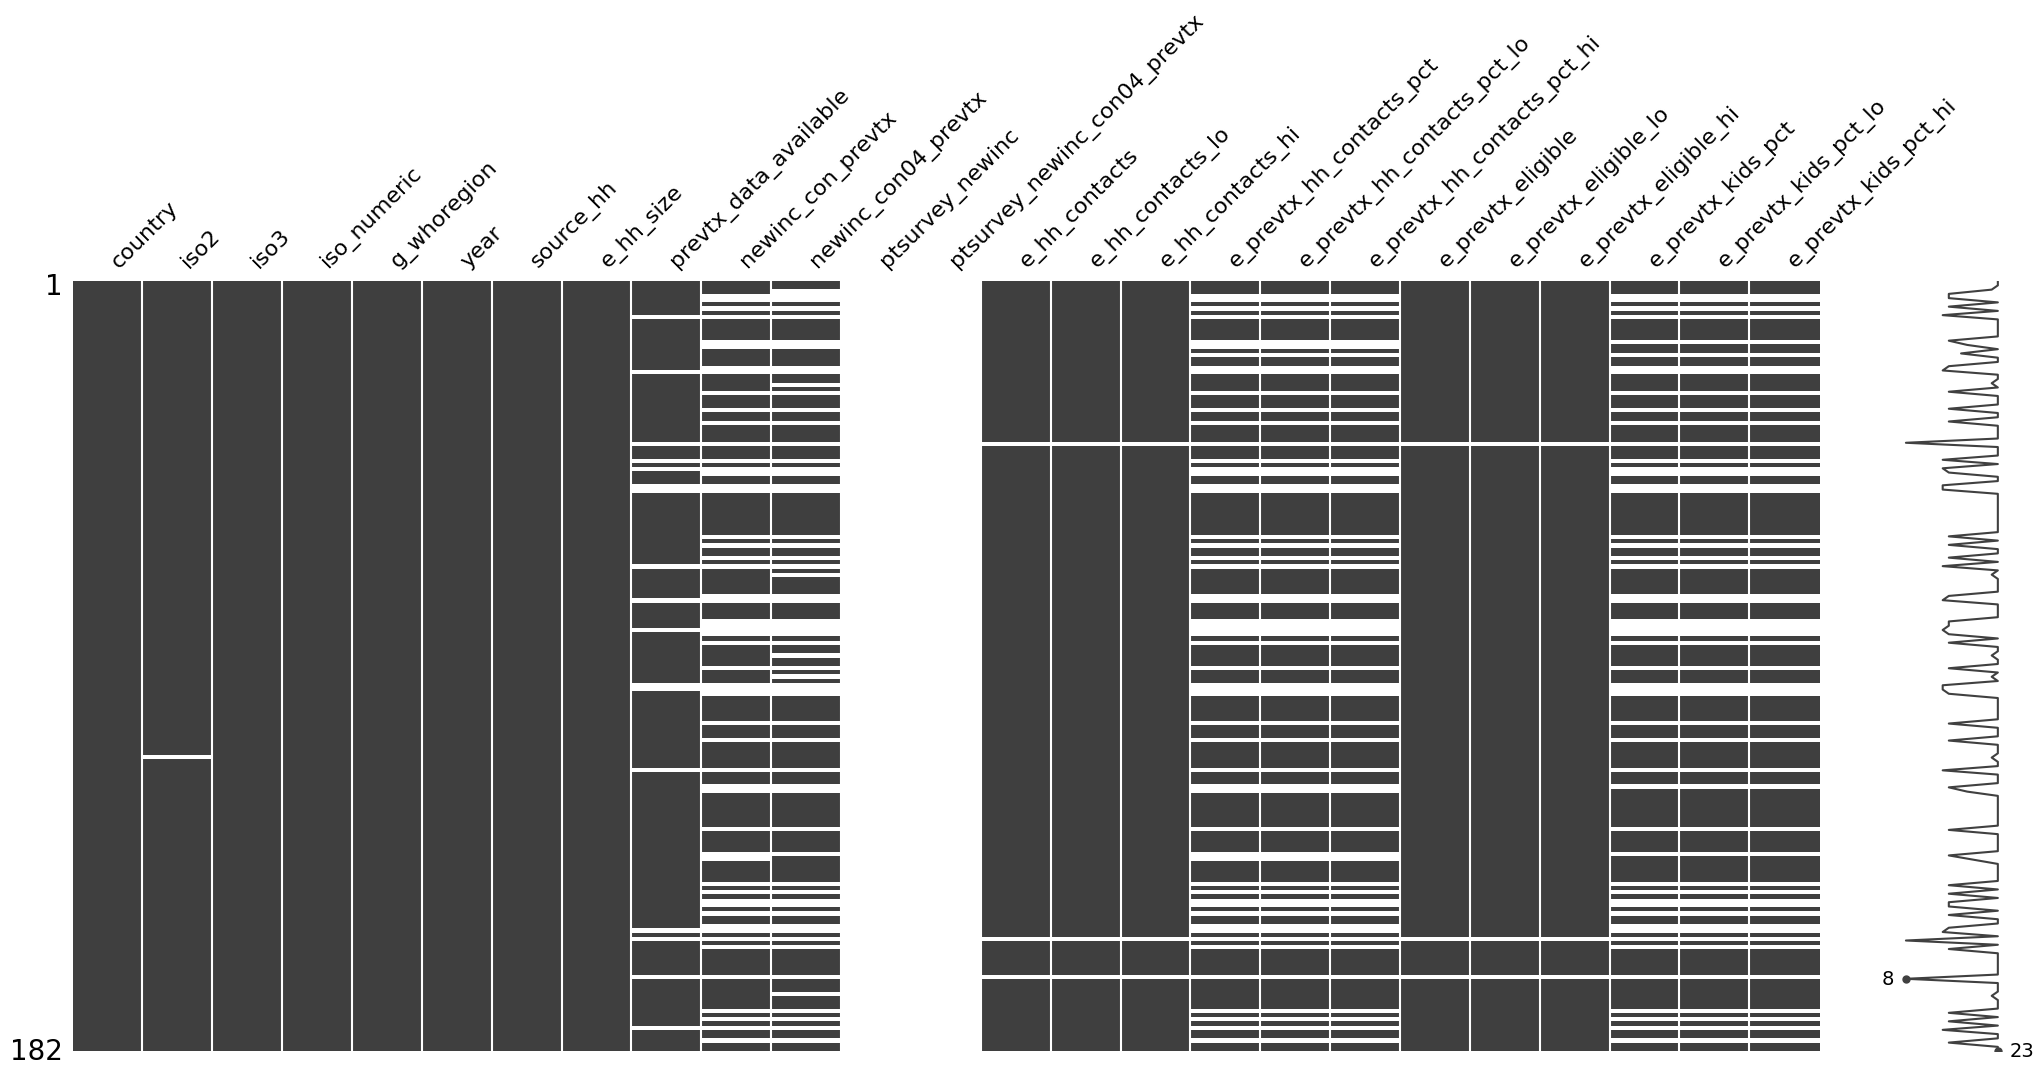

In [54]:
msno.matrix(ltbi_df)

### The LTBI audit shifts:
The recommender's focus toward preventative care, specifically highlighting the high-risk pool of household contacts (e_hh_contacts). While 2022 data shows significant numbers of contacts, the wide standard deviation confirms that infection risk is highly concentrated in specific geographic clusters. The average pediatric preventative treatment rate of only 56% identifies a critical gap in protecting vulnerable child populations, serving as a primary indicator for diagnostic intervention needs. High missingness in follow-up metrics (approx. 30%) suggests that many districts estimate their latent burden but lack the operational capacity to track treatment completion. Integrating these estimates allows the Recommender System to move from a reactive model (treating the sick) to a proactive model (preventing new active cases).

# **PPM**

In [55]:
# Load the ppm file into a dataframe
ppm_path = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/WHO TB dataset_2024-03-21.xlsx - TB_ppm_2024-03-21.csv')
ppm_df = pd.read_csv(ppm_path)

# Display the head of the dataframe
display(ppm_df.head())

,country,iso2,iso3,iso_numeric,g_whoregion,year,priv_new_dx,pub_new_dx
0,Afghanistan,AF,AFG,4,EMR,2010,430.0,840.0
1,Afghanistan,AF,AFG,4,EMR,2011,819.0,825.0
2,Afghanistan,AF,AFG,4,EMR,2012,2128.0,1362.0
3,Afghanistan,AF,AFG,4,EMR,2013,2972.0,2753.0
4,Afghanistan,AF,AFG,4,EMR,2014,2826.0,366.0


In [56]:
# Display the shape of the ppm_df dataframe
print(ppm_df.shape)

(350, 8)


In [57]:
# Display the columns and their data types
print(ppm_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      350 non-null    object 
 1   iso2         350 non-null    object 
 2   iso3         350 non-null    object 
 3   iso_numeric  350 non-null    int64  
 4   g_whoregion  350 non-null    object 
 5   year         350 non-null    int64  
 6   priv_new_dx  340 non-null    float64
 7   pub_new_dx   292 non-null    float64
dtypes: float64(2), int64(2), object(4)
memory usage: 22.0+ KB
None


In [58]:
# Display the statistics
display(ppm_df.describe())

,iso_numeric,year,priv_new_dx,pub_new_dx
count,350.000000,350.000000,340.000000,292.000000
mean,421.551429,2015.937143,28453.055882,16133.917808
std,241.932872,3.721931,88730.104068,42856.831499
min,4.000000,2010.000000,0.000000,0.000000
25%,231.000000,2013.000000,721.500000,214.750000
50%,404.000000,2016.000000,3482.000000,1893.500000
75%,608.000000,2019.000000,16923.000000,6634.500000
max,834.000000,2022.000000,809484.000000,310902.000000


In [59]:
# Calculate the number of missing values
missing_values_count = ppm_df.isnull().sum()

# Calculate the percentage of missing values
missing_values_percentage = (missing_values_count / len(ppm_df)) * 100

# Create a dataframe to display the results
missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

# Sort the dataframe by missing percentage in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the dataframe
display(missing_values_df)

,Missing Count,Missing Percentage (%)
pub_new_dx,58,16.571429
priv_new_dx,10,2.857143
country,0,0.000000
iso2,0,0.000000
iso3,0,0.000000
iso_numeric,0,0.000000
g_whoregion,0,0.000000
year,0,0.000000


<Axes: >

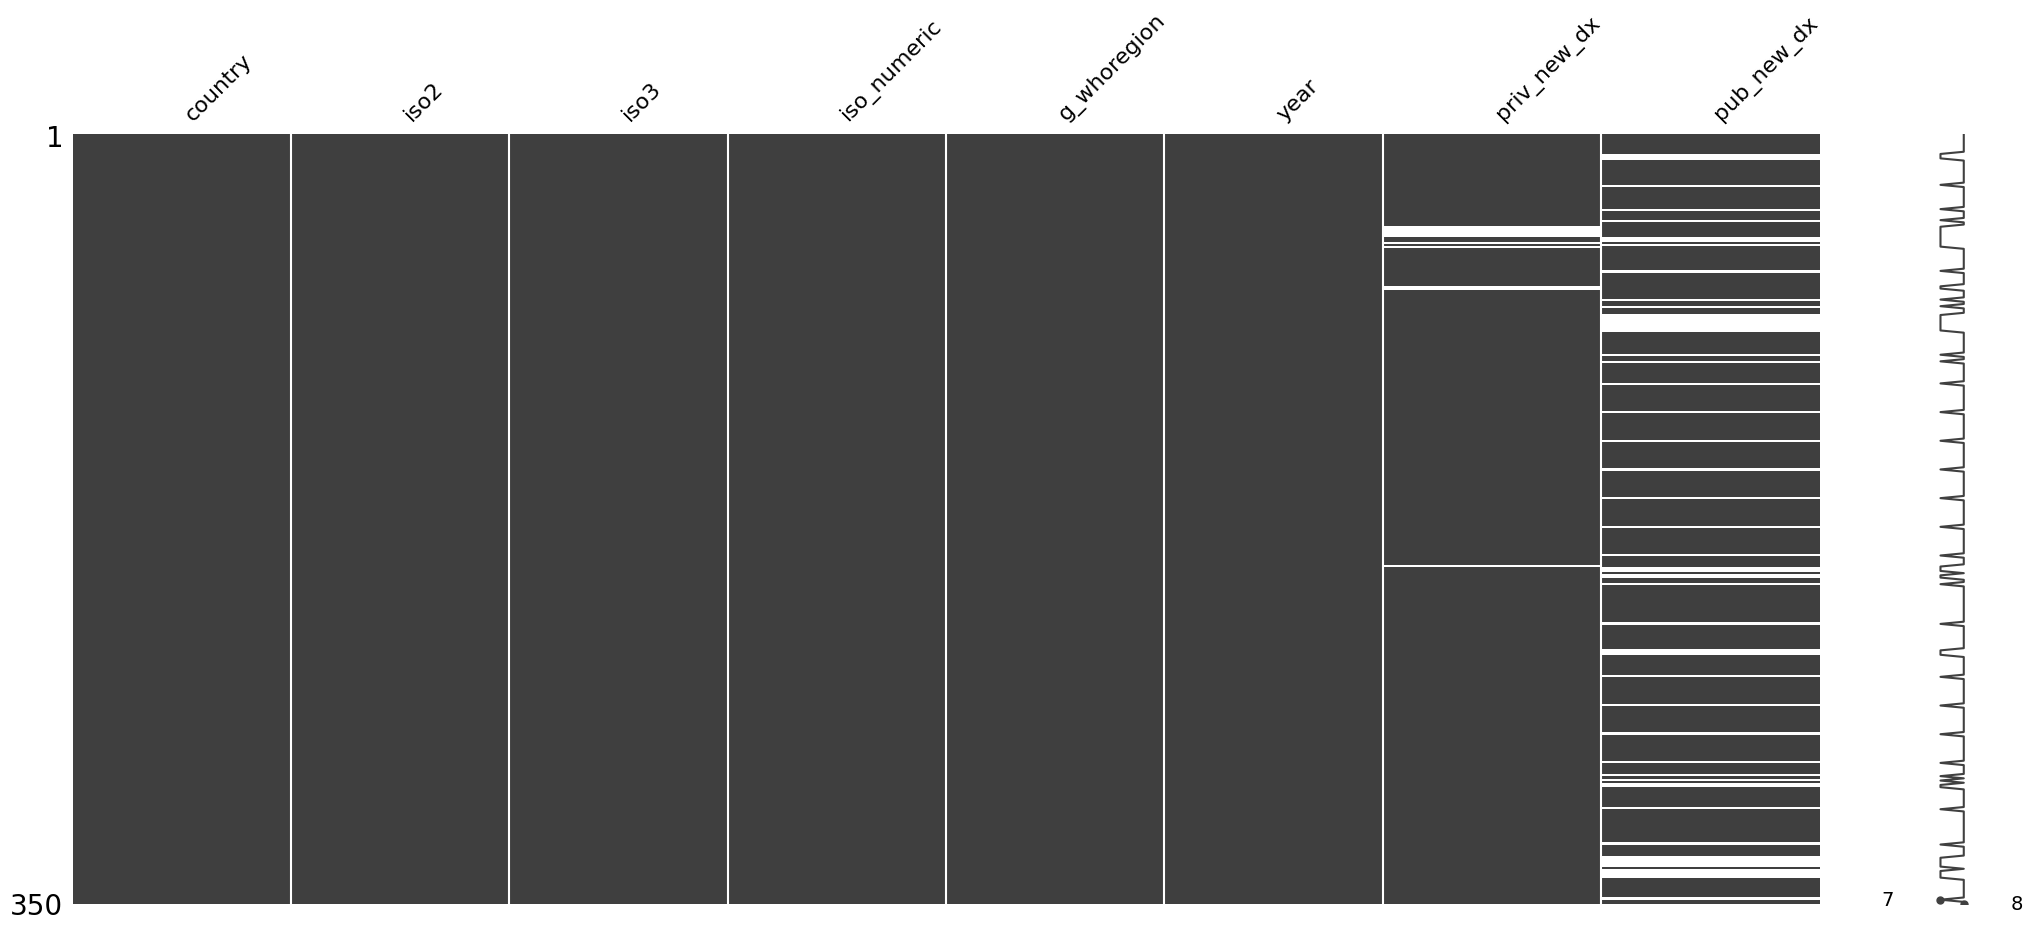

In [60]:
# Visualize the missing data
msno.matrix(ppm_df)

### The PPM audit 
Reveals that the private sector is a dominant force in TB diagnosis within the audited districts, often reporting higher notification volumes (~28.5k mean) than the public sector (~16.1k mean). With a remarkably low missingness rate for private notifications (2.8%), this dataset provides a reliable anchor for understanding where patients first seek care. By calculating a "Private Sector Dependency" ratio, the recommender can distinguish between districts with centralized public health systems and those that require decentralized, private-sector diagnostic interventions. The presence of massive outliers (max notifications over 800k) confirms that diagnostic strategy must be tailored to the specific health-seeking behaviors of each region. This file adds a vital "Market Segment" layer to the project, ensuring recommendations account for both government infrastructure and private provider networks.

#  Phase 1 Conclusion: Data Audit Sign-Off

### Summary of Findings
* **High Confidence:** Epidemiological data (**Burden**) is 100% complete for core metrics, providing a solid anchor for ranking "District Demand."
* **High Sparsity:** **Laboratory quality** and **Financial expenditure** data are fragmented (>50% missing in some regions), requiring us to use proxy variables (like Smear Labs or Facility Visits) in Phase 2.
* **Geographic Clustering:** Subject matter expertise and standard deviation analysis confirm that capacity and funding are not randomly missing but vary by region, necessitating **Regional Imputation** and **Normalization**.

### Next Steps: Phase 2 - Data Preprocessing
With the audit complete, we will now proceed to:
1.  **The Master Merge:** Combining these 8 files into a single "Source of Truth" using `iso3` and `year`.
2.  **Feature Engineering:** Creating the "Efficiency Ratio" (Spending vs. Success) and "Prevention Gap" (LTBI vs. TPT).
3.  **Scaling:** Normalizing high-volume countries (like India) against smaller districts to ensure equitable recommendations.

---
**Data Audit Status: COMPLETE**